# Author : Vishnu Kumar DS
# GRIP @ THE SPARK FOUNDATION 

# TASK 3 
## USING Sample store dataset apply EDA on that and Find the area where we can make more Profits 

# Imports Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import Dataset

In [2]:
data = pd.read_csv("SampleSuperstore.csv")

In [3]:
data.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


# Describe about Data

In [4]:
data.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [6]:
# Check the null values
data.isnull()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,False,False,False,False,False,False,False,False,False,False,False,False,False
9990,False,False,False,False,False,False,False,False,False,False,False,False,False
9991,False,False,False,False,False,False,False,False,False,False,False,False,False
9992,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
data.isnull().any().sum()

0

In [8]:
# From the above data
# We can say that there is no NUll values in dataset 

In [9]:
# Let we check the duplictae VAlues in DataSet

In [10]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9989    False
9990    False
9991    False
9992    False
9993    False
Length: 9994, dtype: bool

In [11]:
data.duplicated().sum()

17

In [12]:
# Before drop duplicate values
data.shape

(9994, 13)

In [13]:
#  There are 17 rows which are null so we drop them
data1 = data.drop_duplicates()

In [14]:
data1.shape

(9977, 13)

##### The nunique() method returns the number of unique values for each column. By specifying the column axis ( axis='columns' ), the nunique() method searches column-wise and returns the number of unique values for each row.

In [15]:
data1.nunique()

Ship Mode          4
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
Category           3
Sub-Category      17
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

In [16]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [17]:
# From the above we can see that Postal Code do not play important ROLE so we can delete it.
data2 = data1.drop(columns='Postal Code',axis=1)

In [18]:
data2.head()

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [19]:
# Correlation between the Variable
data2.corr()

C:\Users\vishn\AppData\Local\Temp\ipykernel_12428\3409725826.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  data2.corr()


,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200722,-0.028311,0.479067
Quantity,0.200722,1.000000,0.008678,0.066211
Discount,-0.028311,0.008678,1.000000,-0.219662
Profit,0.479067,0.066211,-0.219662,1.000000


In [20]:
# Covariance 
data2.cov()

C:\Users\vishn\AppData\Local\Temp\ipykernel_12428\2870251327.py:2: FutureWarning: The default value of numeric_only in DataFrame.cov is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  data2.cov()


,Sales,Quantity,Discount,Profit
Sales,389028.396022,278.765576,-3.645637,70057.067126
Quantity,278.765576,4.958001,0.003990,34.565743
Discount,-3.645637,0.003990,0.042624,-10.632751
Profit,70057.067126,34.565743,-10.632751,54970.478824


In [21]:
data2.head()

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [22]:
data2["State"].value_counts()

California              1996
New York                1127
Texas                    983
Pennsylvania             586
Washington               502
Illinois                 491
Ohio                     468
Florida                  383
Michigan                 254
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   123
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Oklahoma                  66
Missouri                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Utah                      53
Mississippi               53
Louisiana                 42
South Carolina            42
Nevada        

In [23]:
# Let We see States with respective Sales          

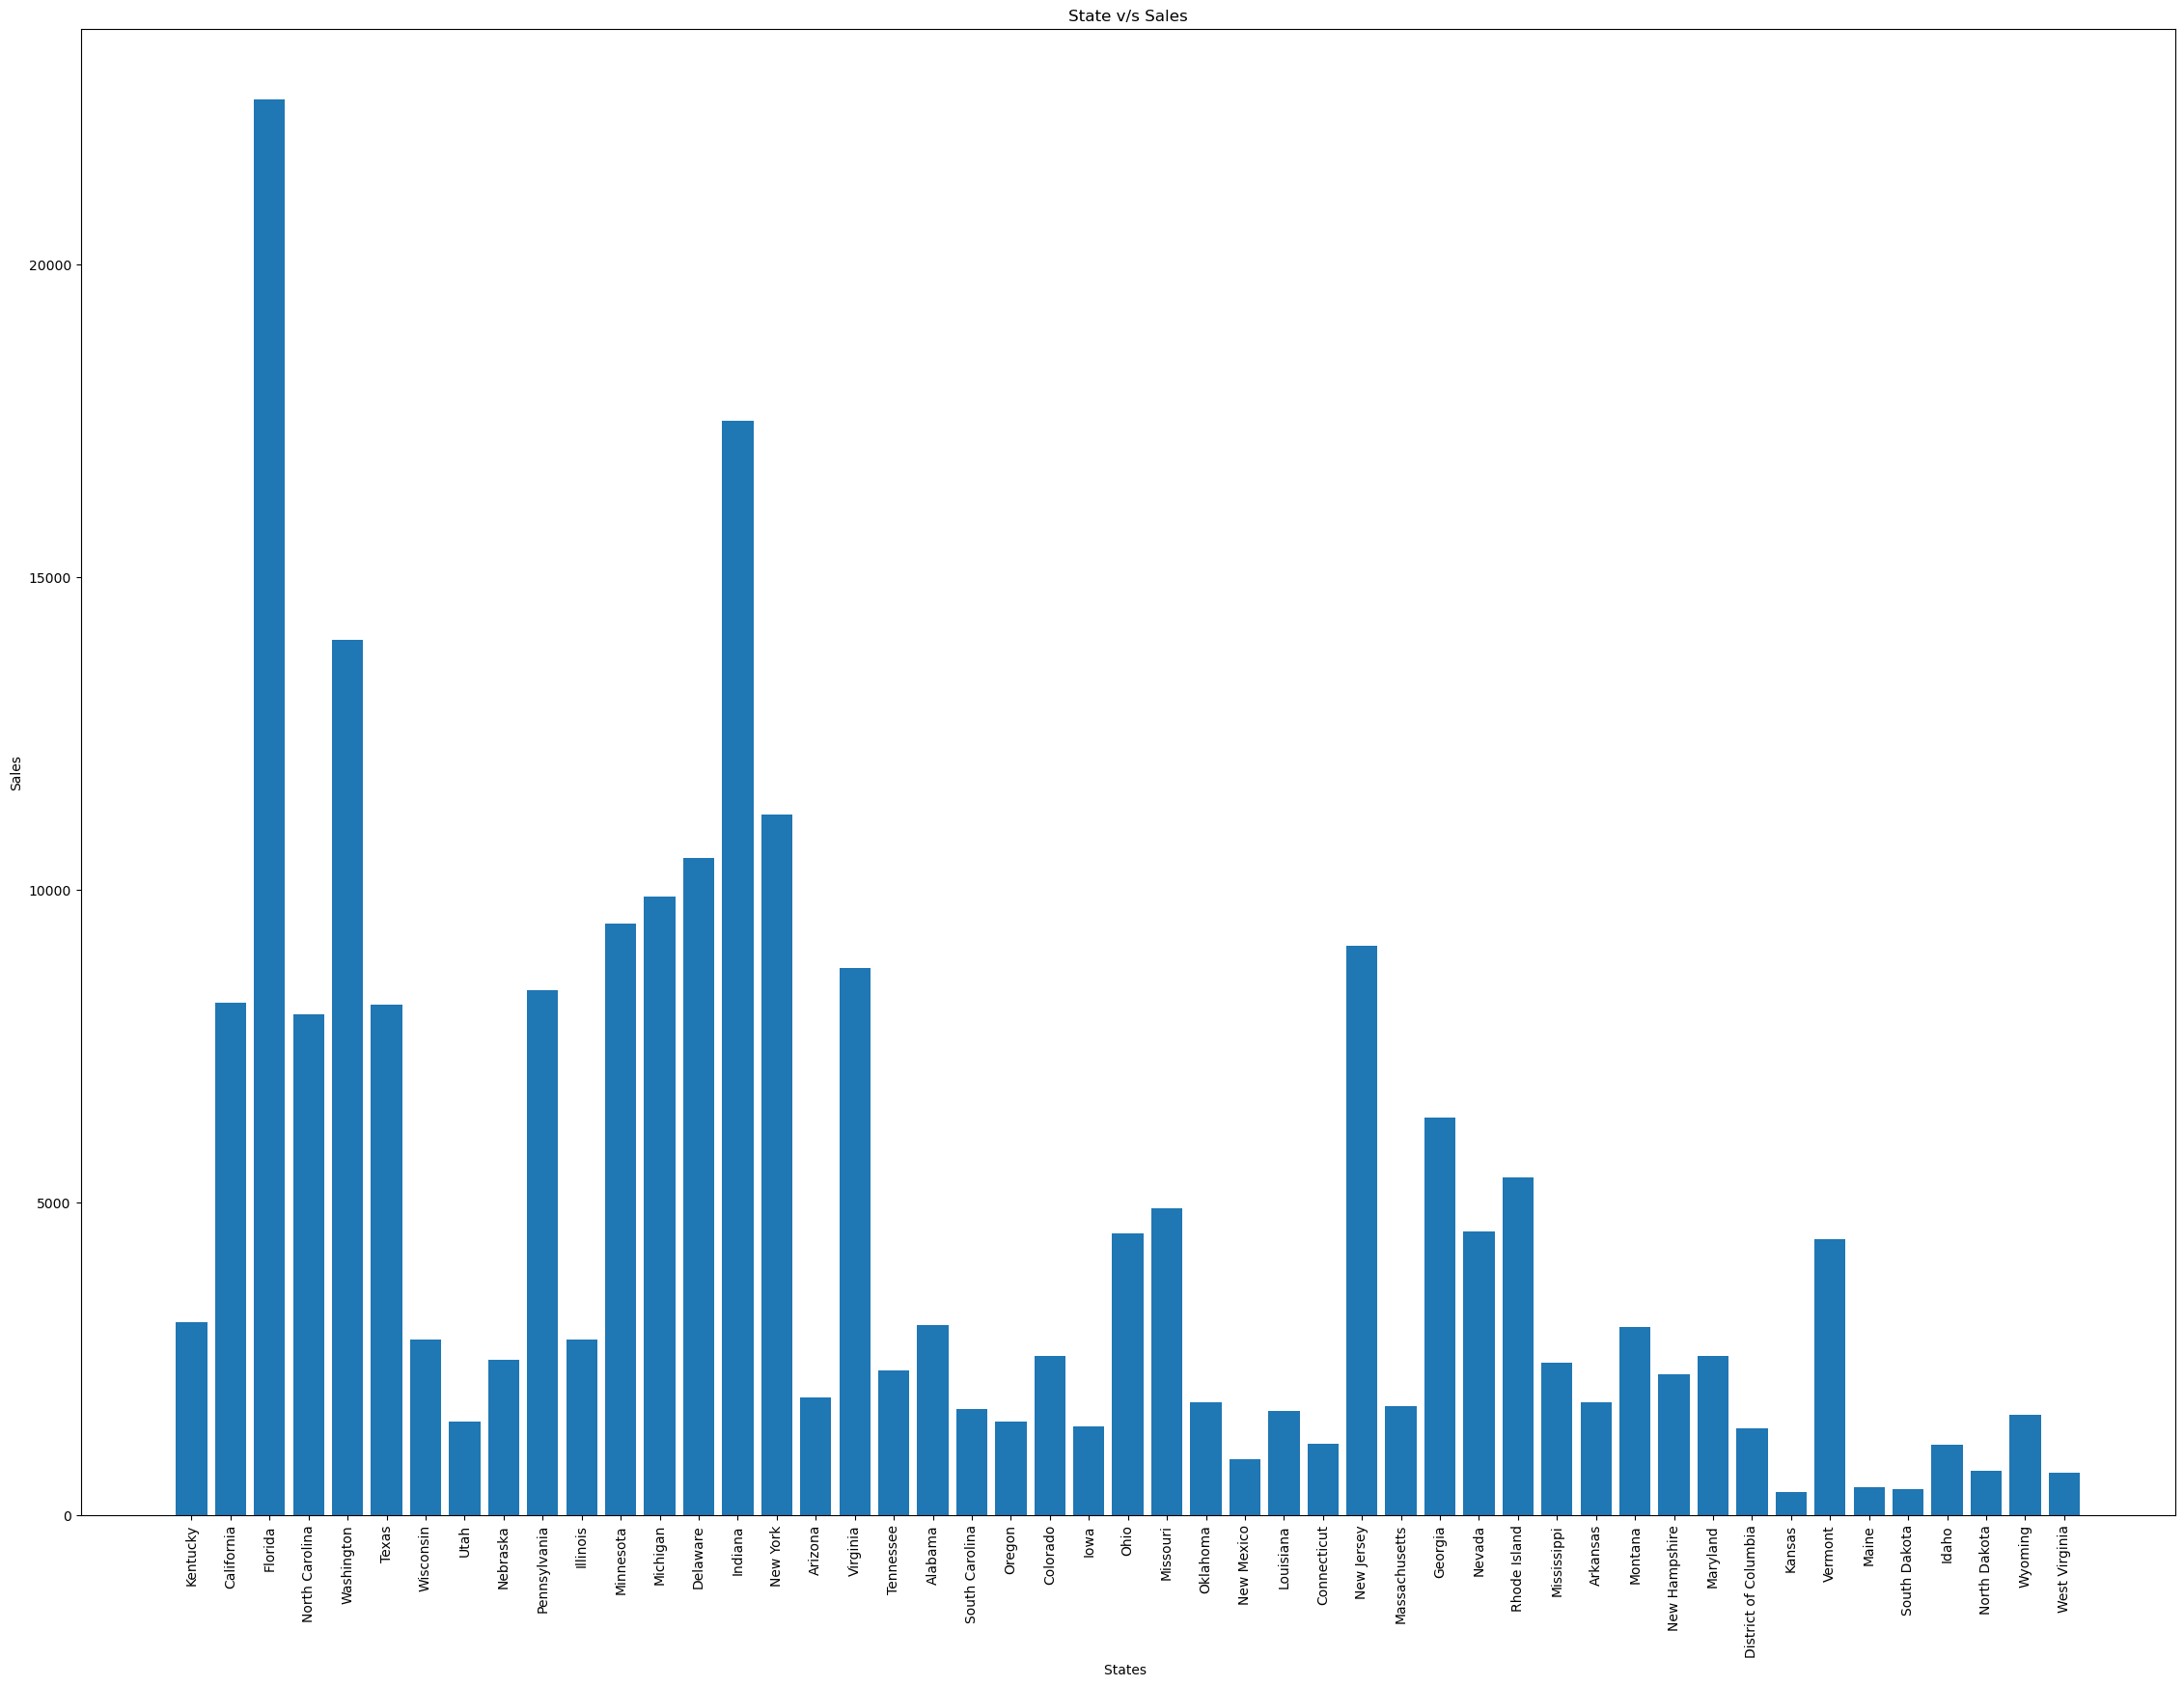

In [24]:
plt.figure(figsize=(28,20))
plt.bar("State","Sales",data=data2)
plt.title("State v/s Sales")
plt.xlabel("States ")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

C:\Users\vishn\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


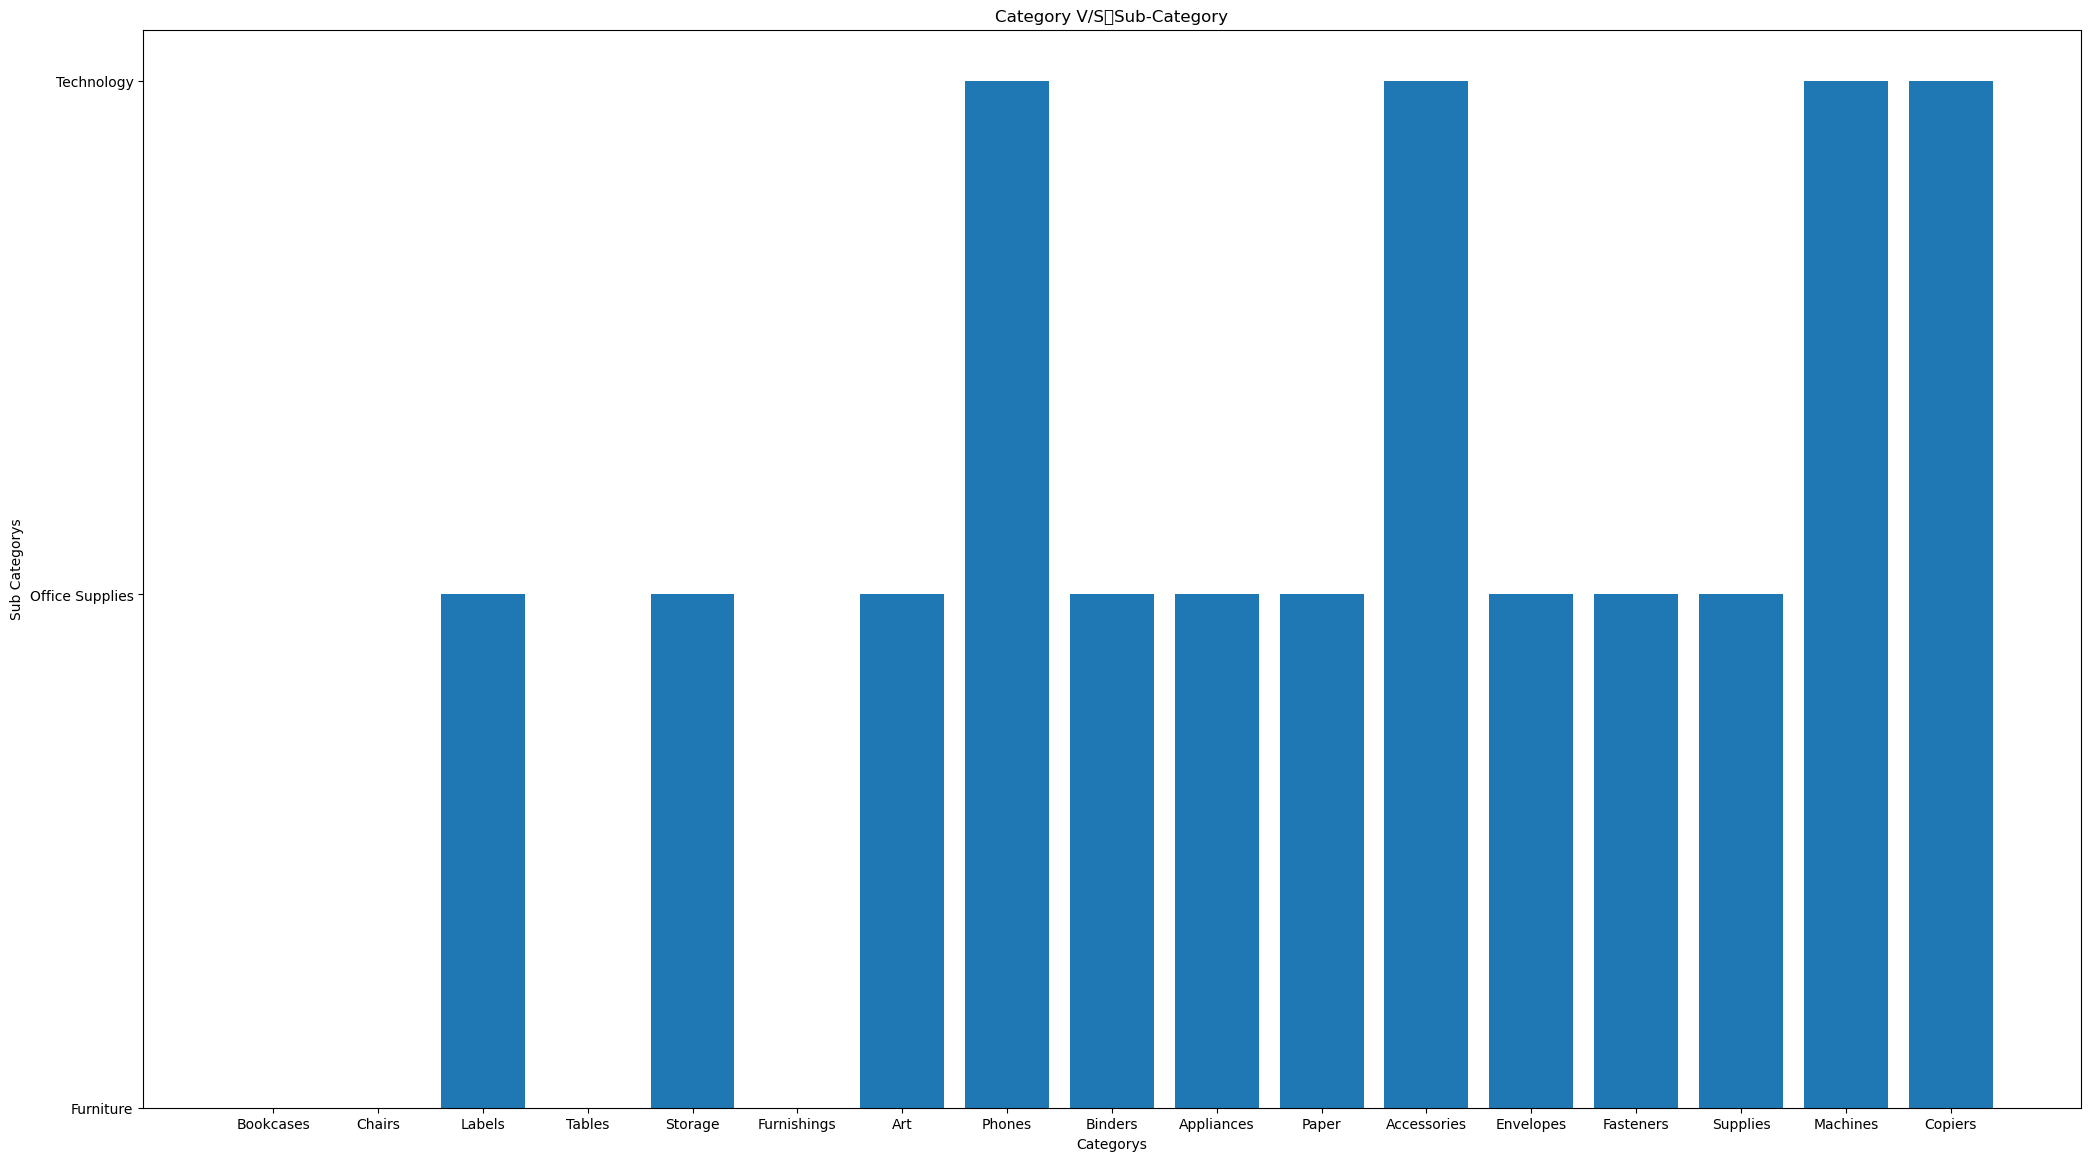

In [25]:
plt.figure(figsize=(25,14))
plt.bar("Sub-Category","Category",data=data2)
plt.xlabel("Categorys")
plt.ylabel("Sub Categorys")
plt.title("Category V/S	Sub-Category")
plt.show()

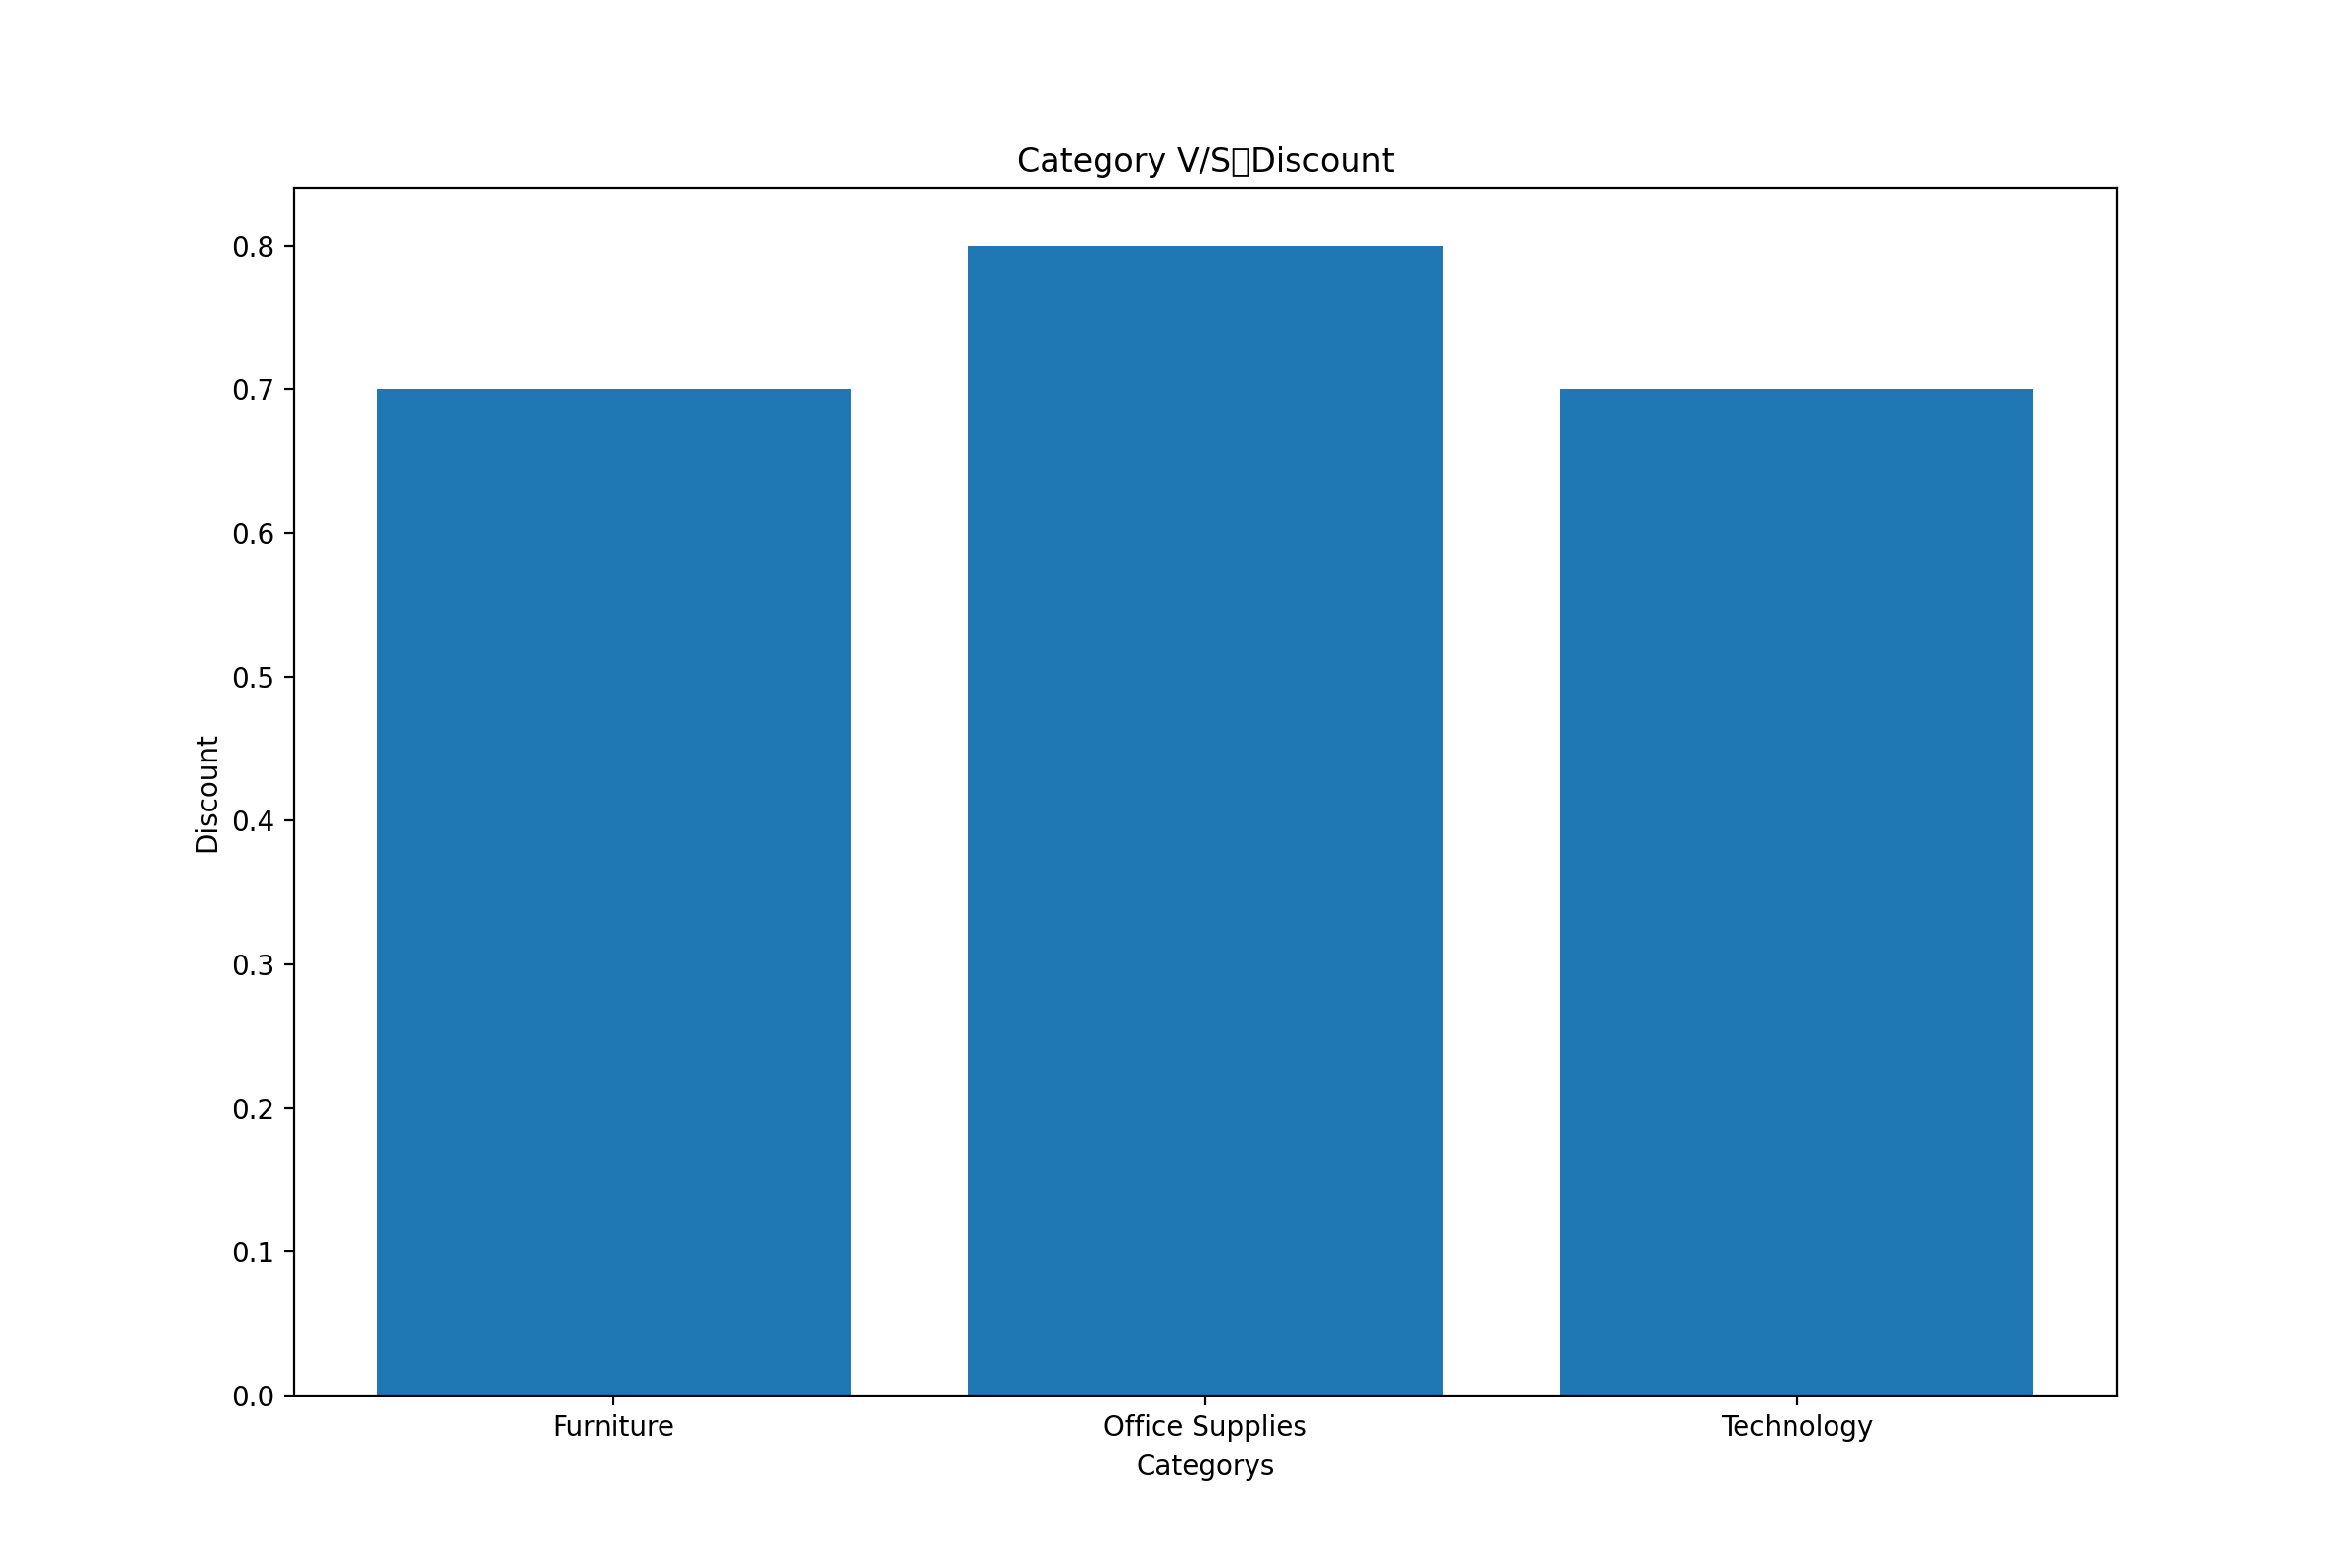

In [46]:
plt.figure(figsize=(12,8))
plt.bar("Category","Discount",data=data2)
plt.xlabel("Categorys")
plt.ylabel("Discount")
plt.title("Category V/S	Discount")
plt.show()

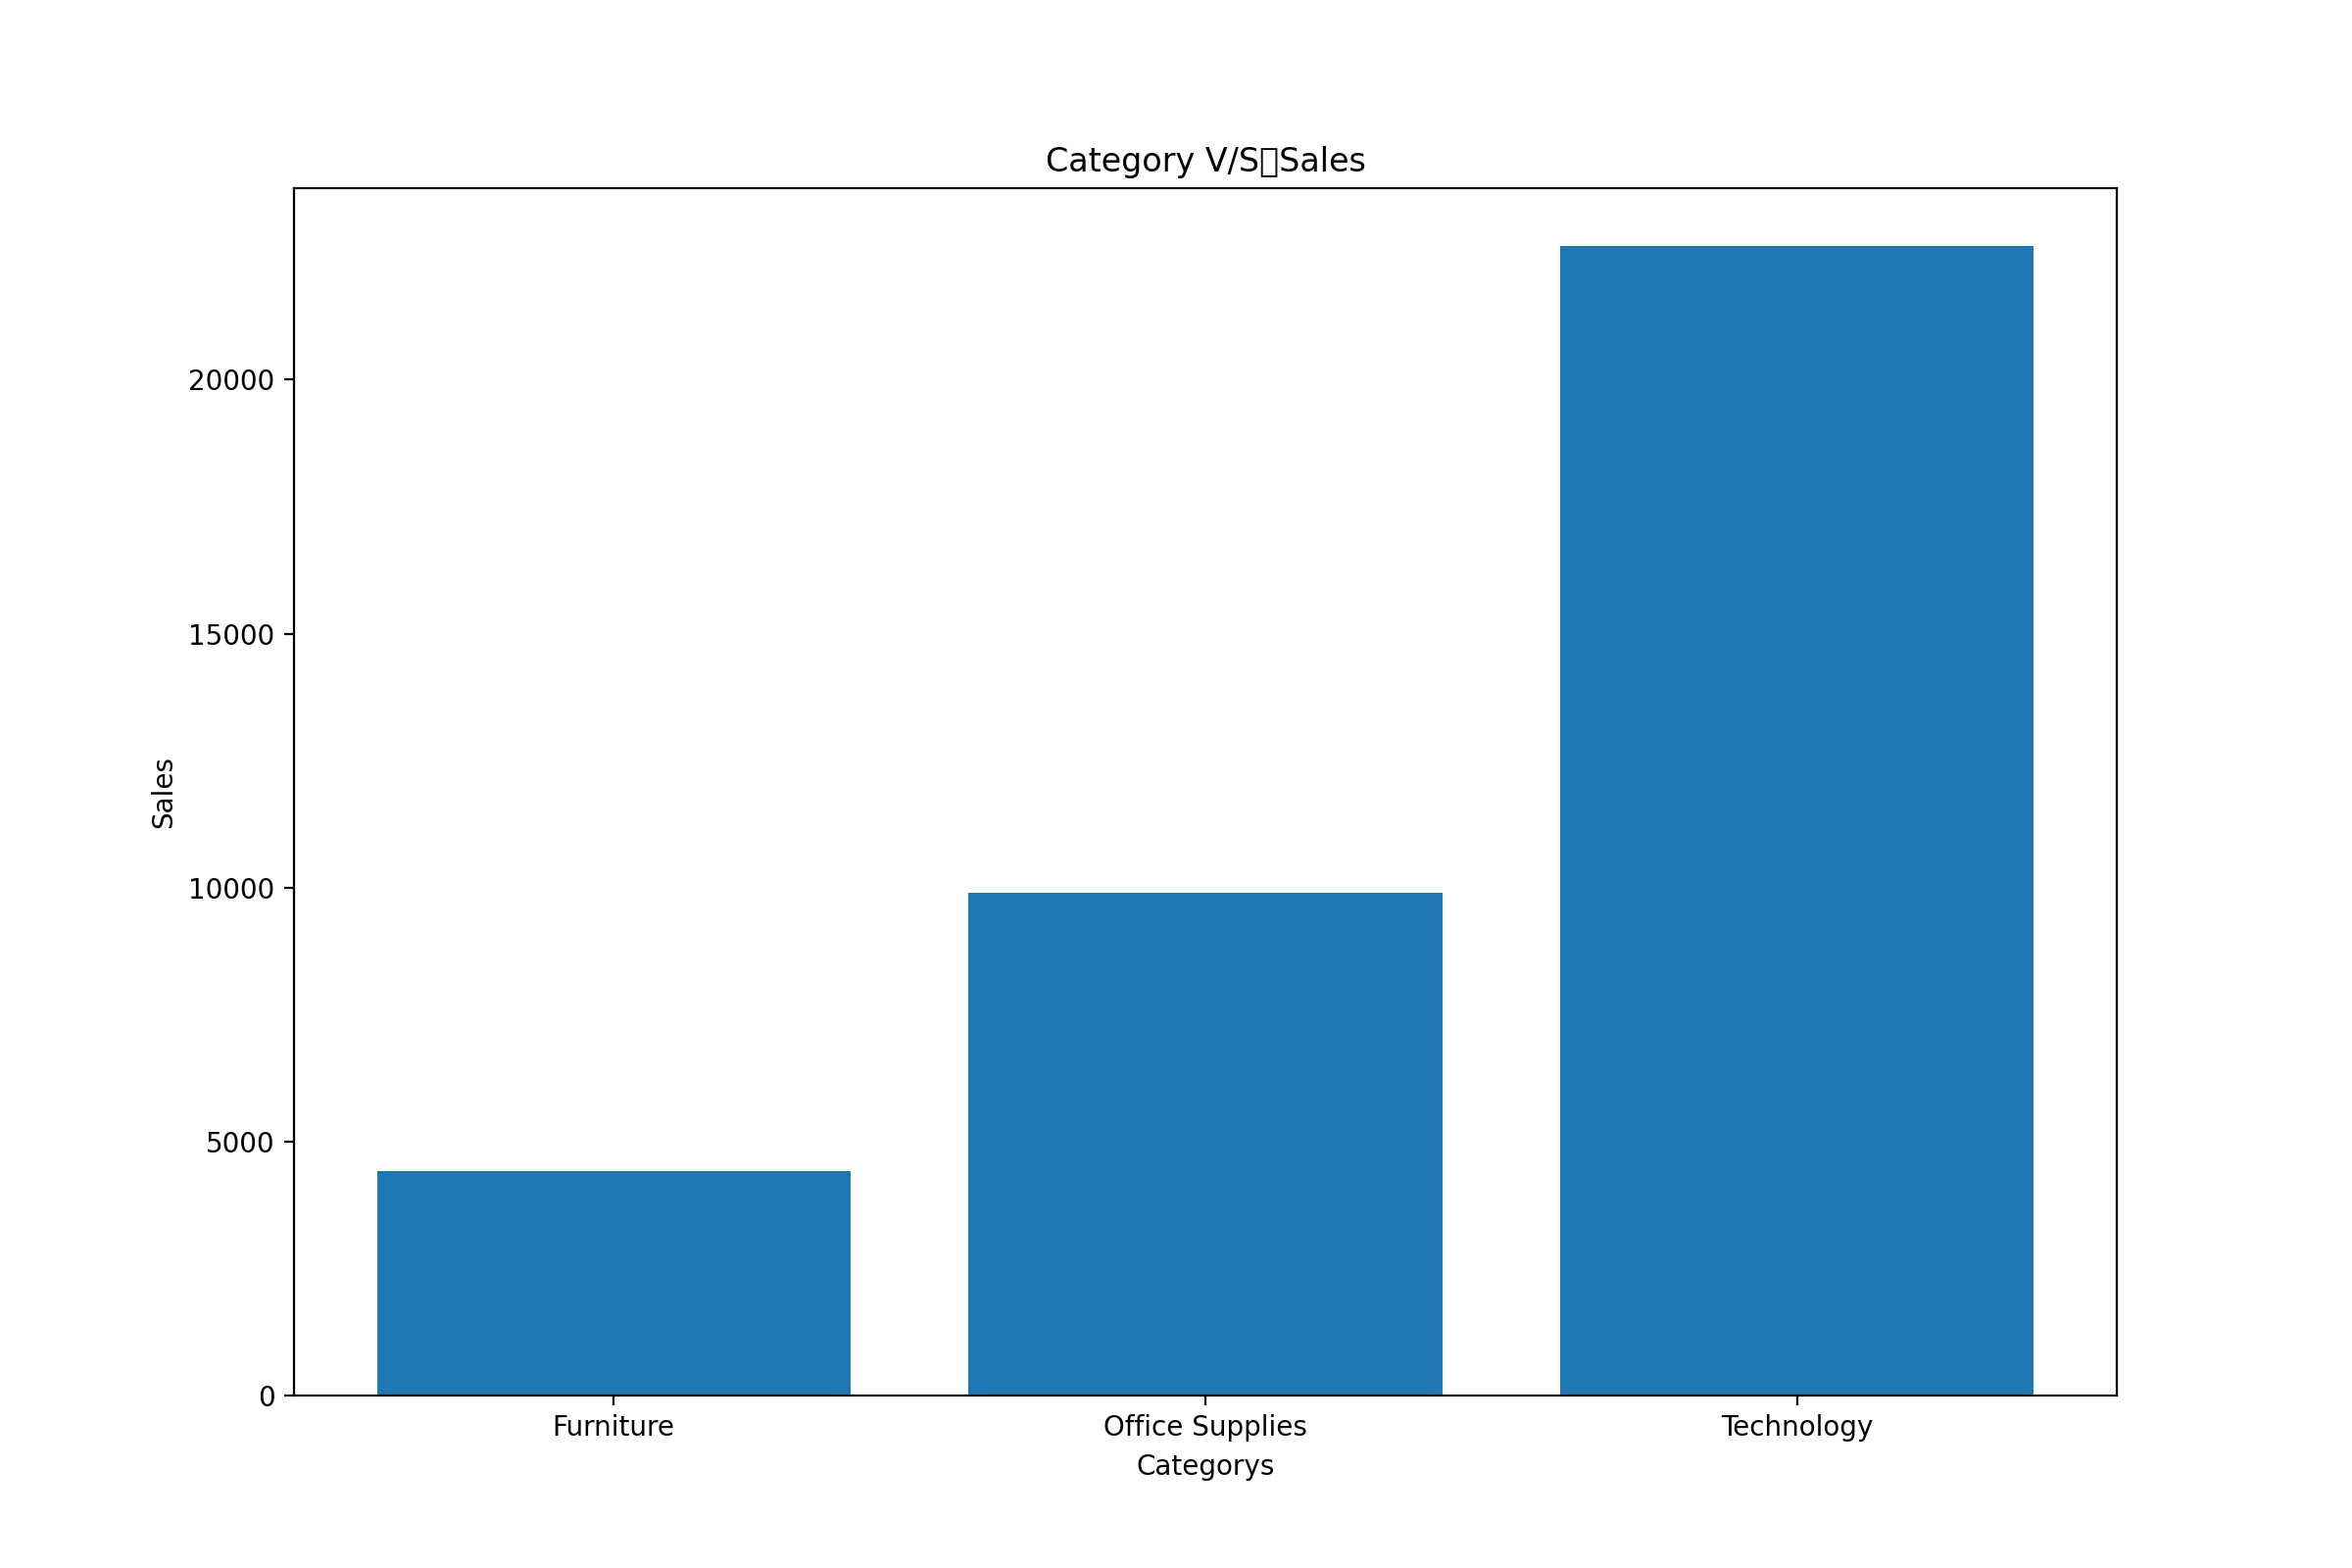

In [42]:
plt.figure(figsize=(12,8))
plt.bar("Category","Sales",data=data2)
plt.xlabel("Categorys")
plt.ylabel("Sales")
plt.title("Category V/S	Sales")
plt.show()

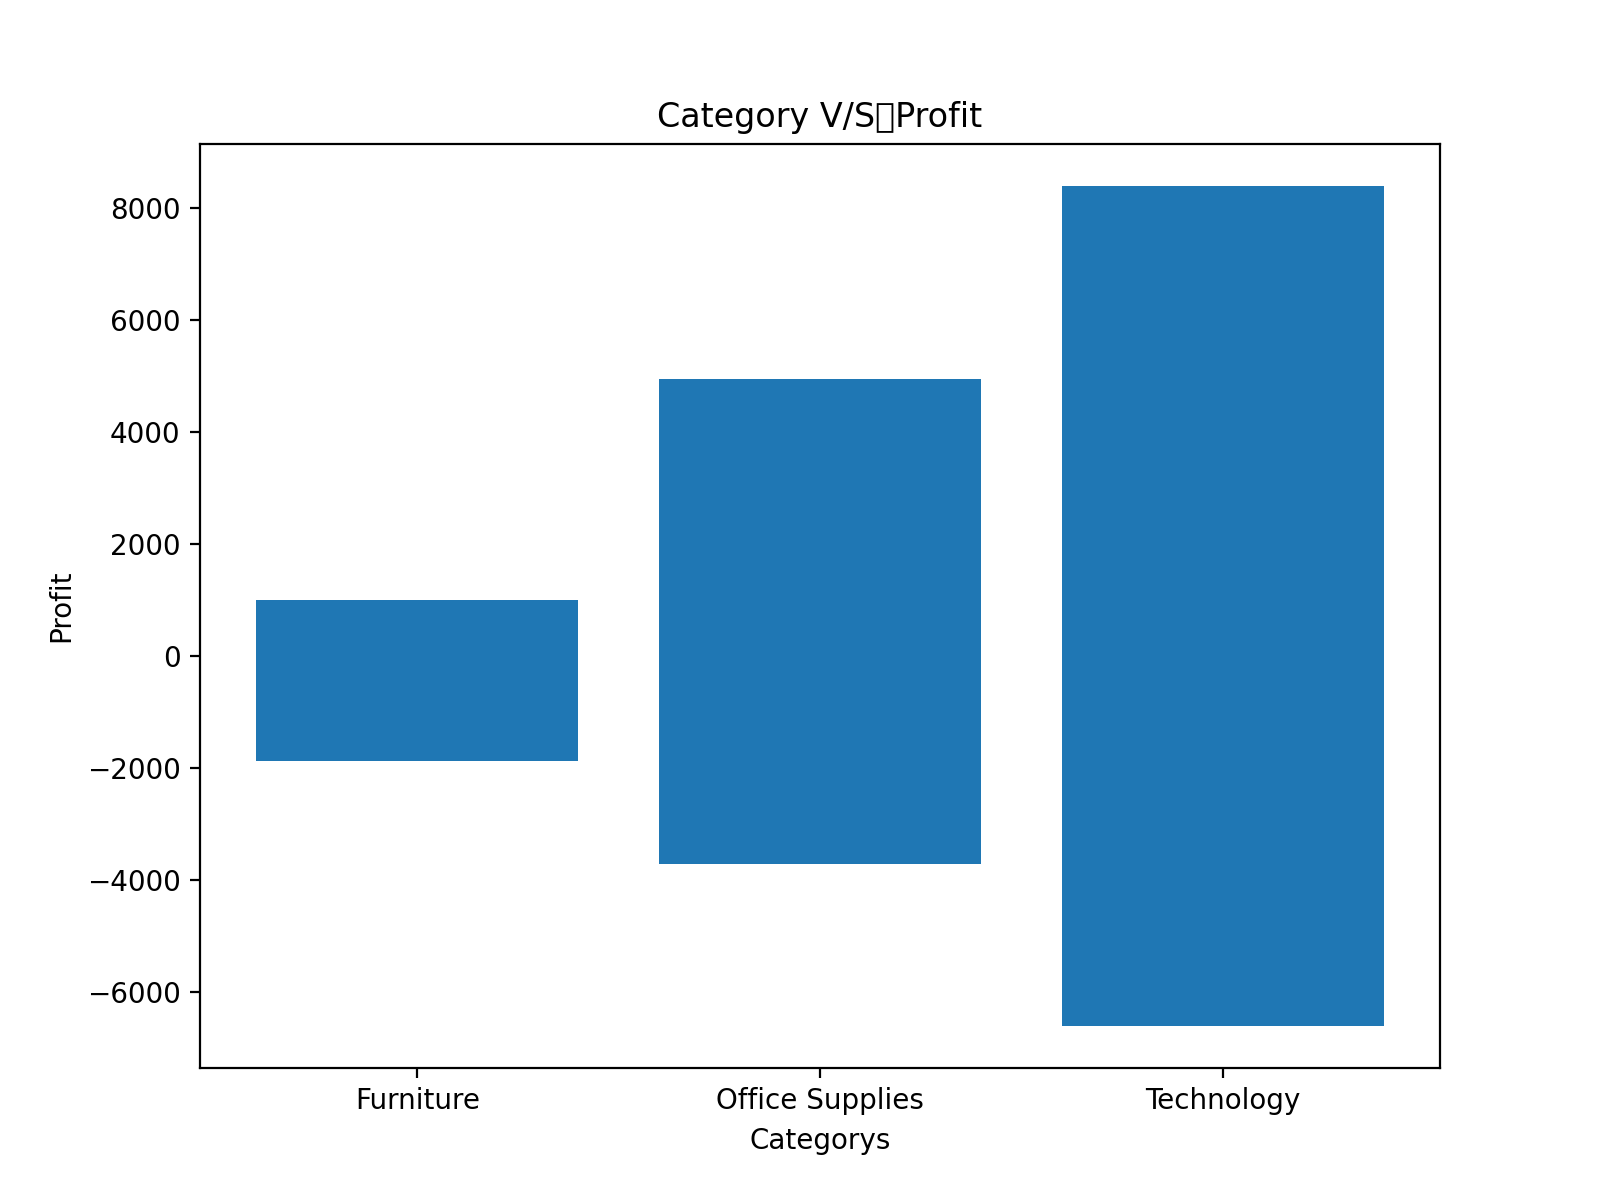

In [44]:
plt.figure(figsize=(8,6))
plt.bar("Category","Profit",data=data2)
plt.xlabel("Categorys")
plt.ylabel("Profit")
plt.title("Category V/S	Profit")
plt.show()

C:\Users\vishn\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.


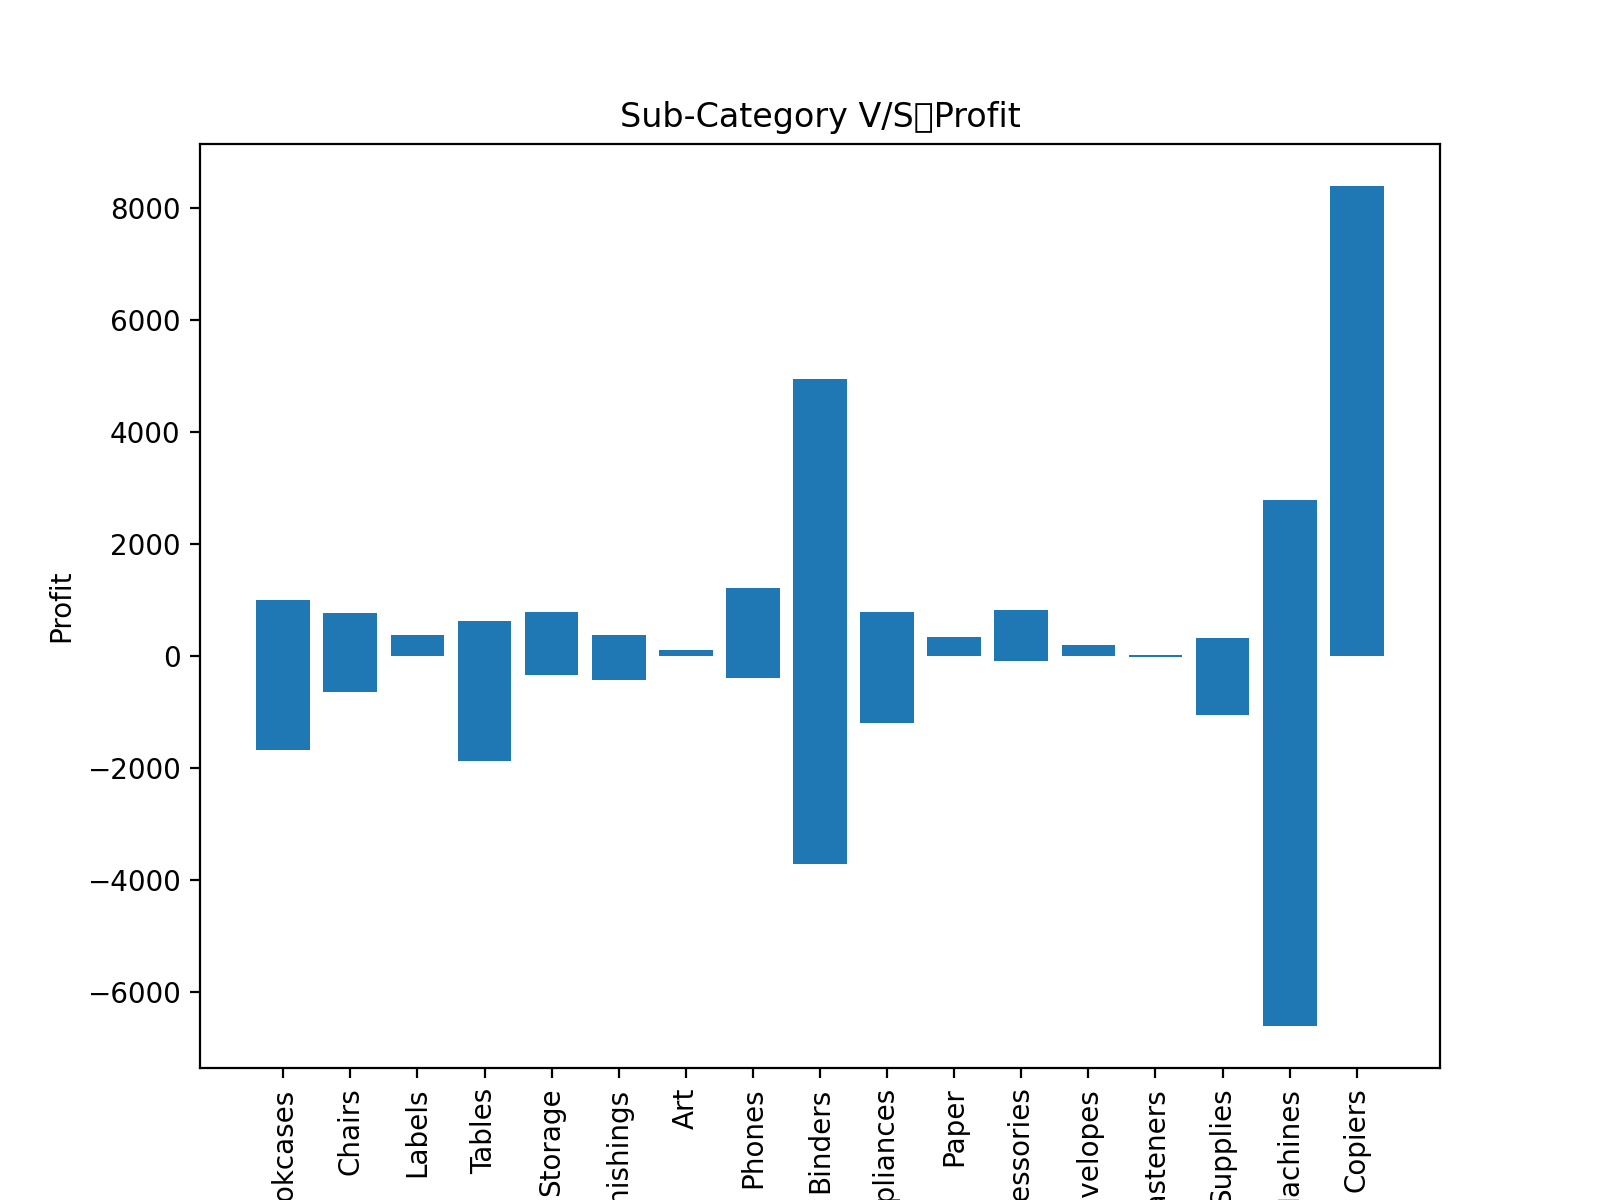

In [47]:
plt.figure(figsize=(8,6))
plt.bar("Sub-Category","Profit",data=data2)
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.title("Sub-Category V/S	Profit")
plt.show()

In [26]:
# We are taking bin as 50 and ploting Sales,Quantity and Discount and Profit

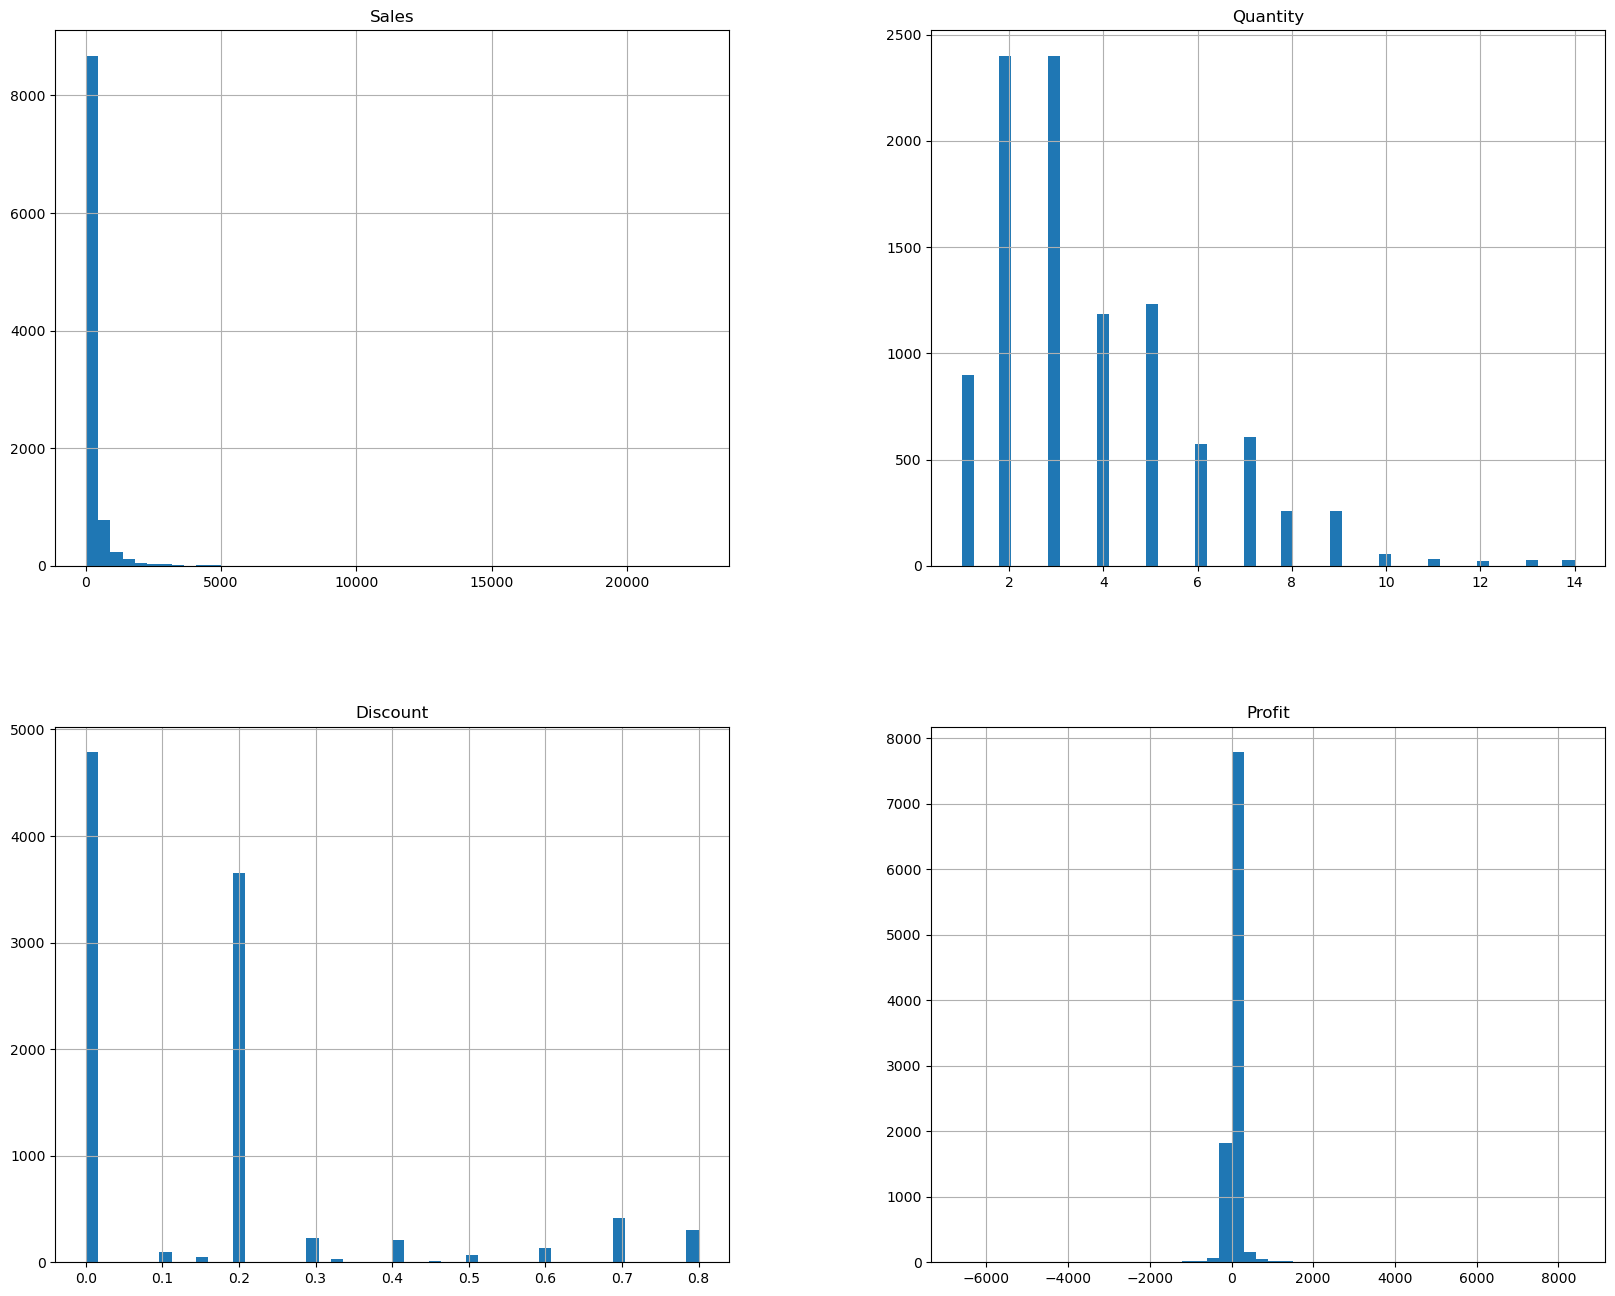

In [27]:
data2.hist(bins=50,figsize=(20,16))
plt.show()

In [28]:
# From the above bar plot we can say that data is not Normal
# Which means,If the graph is approximately bell-shaped and symmetric about the mean, you can usually assume normality. 

In [29]:
import seaborn as sns

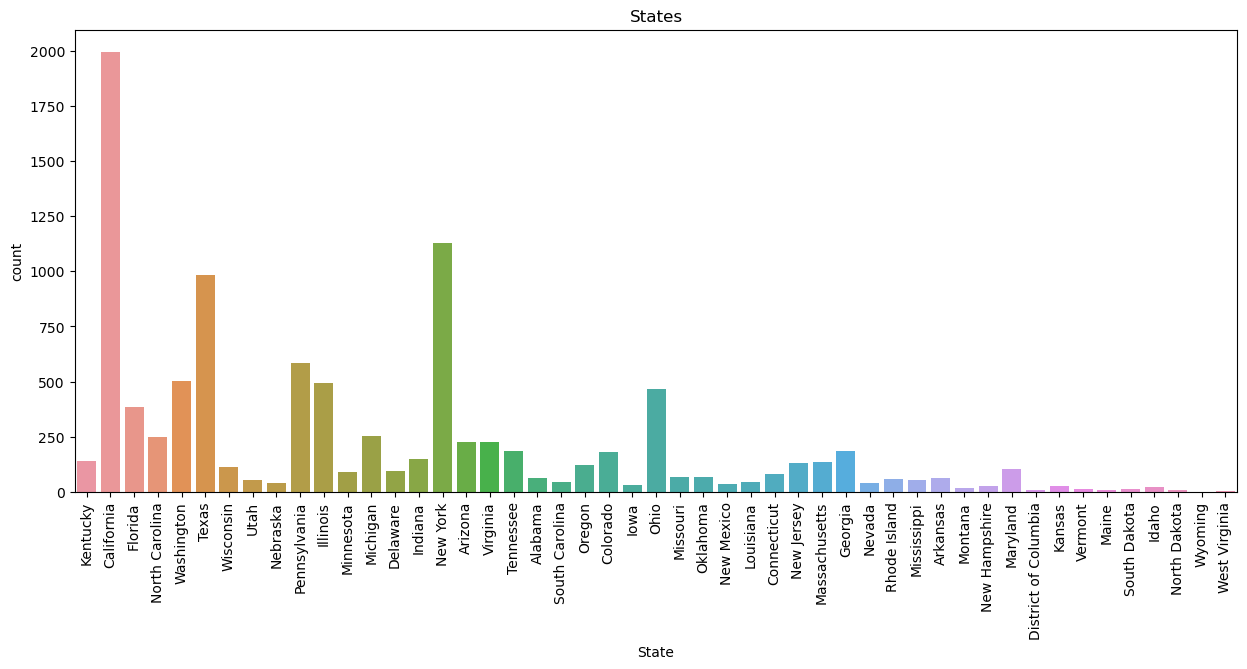

In [30]:
plt.figure(figsize=(15,6))
sns.countplot(x=data2["State"])
plt.xticks(rotation=90)
plt.title("States")
plt.show()

In [31]:
# Install plotnine 

In [32]:
pip install plotnine

Note: you may need to restart the kernel to use updated packages.


In [33]:
# GGPLOT Standers for Grammar of Graphics Plot

In [32]:
from plotnine import *

C:\Users\vishn\anaconda3\Lib\site-packages\mizani\palettes.py:419: UserWarning: Warning message:Brewer palette Spectral has a maximum of 11 colors Returning the palette you asked for with that many colors
C:\Users\vishn\anaconda3\Lib\site-packages\mizani\palettes.py:419: UserWarning: Warning message:Brewer palette Spectral has a maximum of 11 colors Returning the palette you asked for with that many colors


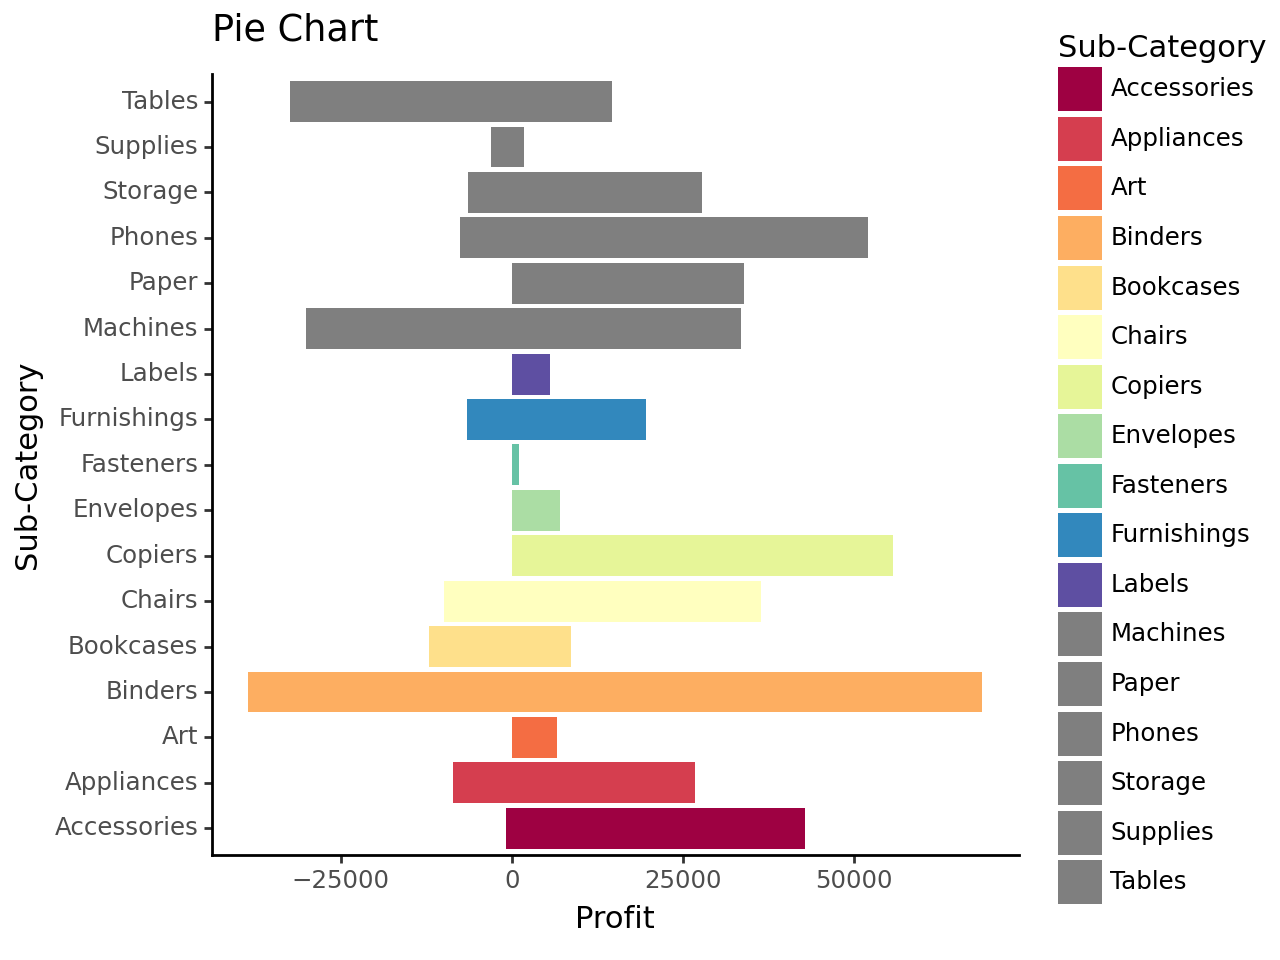

<Figure Size: (640 x 480)>

In [33]:
gain = (ggplot(data1, aes(x="Sub-Category",y="Profit",fill="Sub-Category"))+geom_col()+coord_flip()+scale_fill_brewer(type='div',palette="Spectral")
        +theme_classic() + ggtitle('Pie Chart'))
display(gain)

# Explained above code
aes stands for aesthetic, and it's used to define how variables map to visual properties. In this case:
'Sub-Category' is mapped to the x-axis.
'Profit' is mapped to the y-axis.
'Sub-Category' is also used to fill the bars with different colors.

+ geom_col()
Adds a column chart (bar plot) layer to the plot. This will create vertical bars for each combination of sub-category and profit.

+ coord_flip()
Flips the coordinates, switching the x and y axes. This is commonly used for horizontal bar charts.

+ scale_fill_brewer(type='div', palette="Spectral")
Sets the color palette for filling the bars. It uses a diverging (div) palette named "Spectral" from the Brewer color scales.

+ theme_classic()
Applies a classic theme to the plot. Themes control the overall appearance of the plot, and here, it gives a classic, clean look.

+ ggtitle('Pie Chart')
Adds a title to the plot, though it mentions 'Pie Chart,' which might be a mistake in the title.
display(gain)

### "Copiers" Sub-category has gain highest amount of profit with no loss.There are other sub-categories too who are not faced any kind of losses but their profit margins are also low. Next,Suffering from highest loss is machines.

In [36]:
data1.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [38]:
# We will classify the Catrgory with respect to Ship Mode Where we can improve our sales 

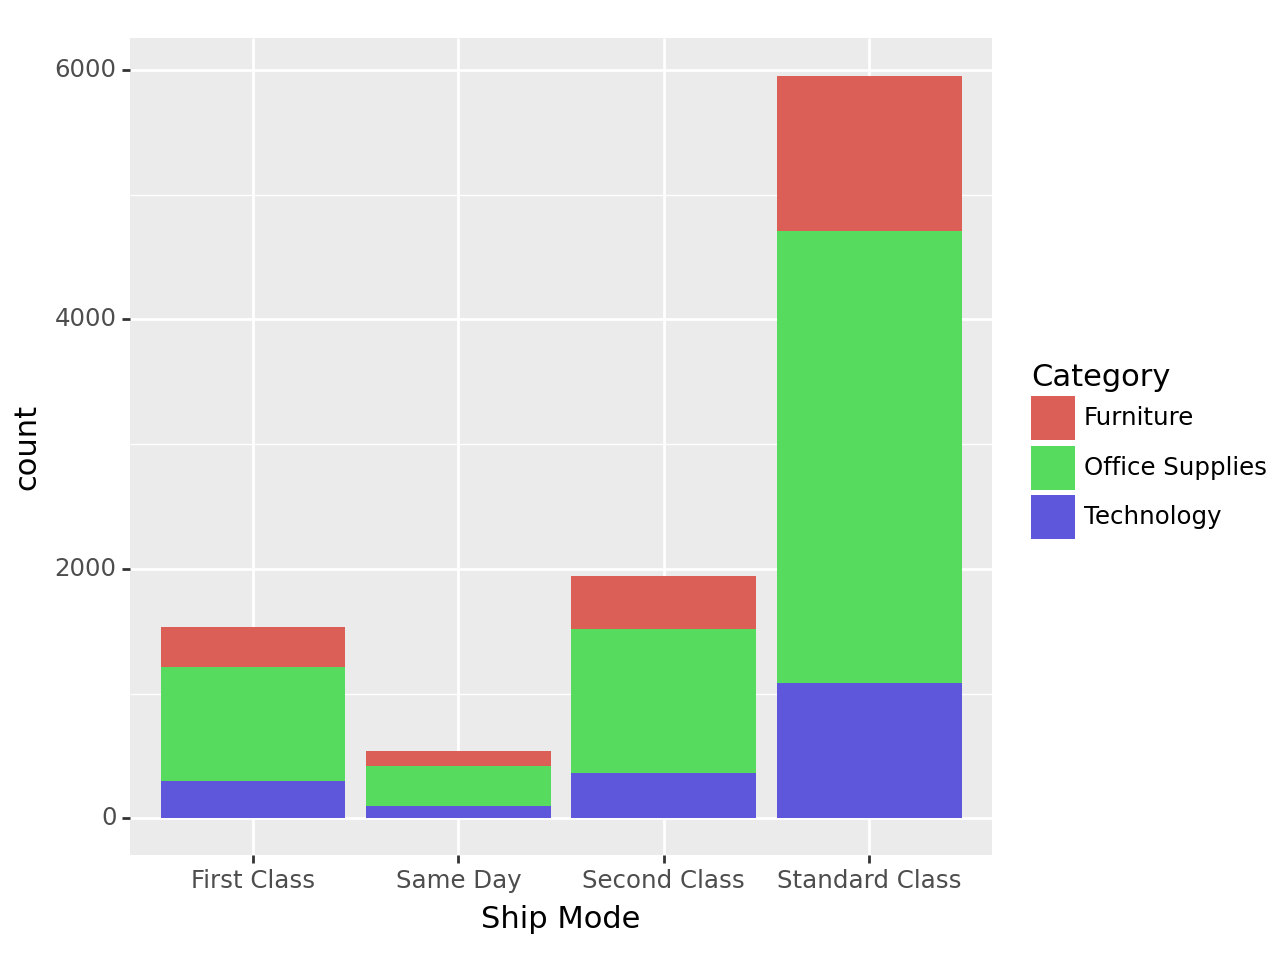

<Figure Size: (640 x 480)>

In [34]:
ggplot(data2, aes(x='Ship Mode',fill="Category")) + geom_bar(stat="count")

In [ ]:
# From the above data We can see that Statndard Class buy more Furniture,Office Supplies and Technology.
# And then Second Class peoples also.

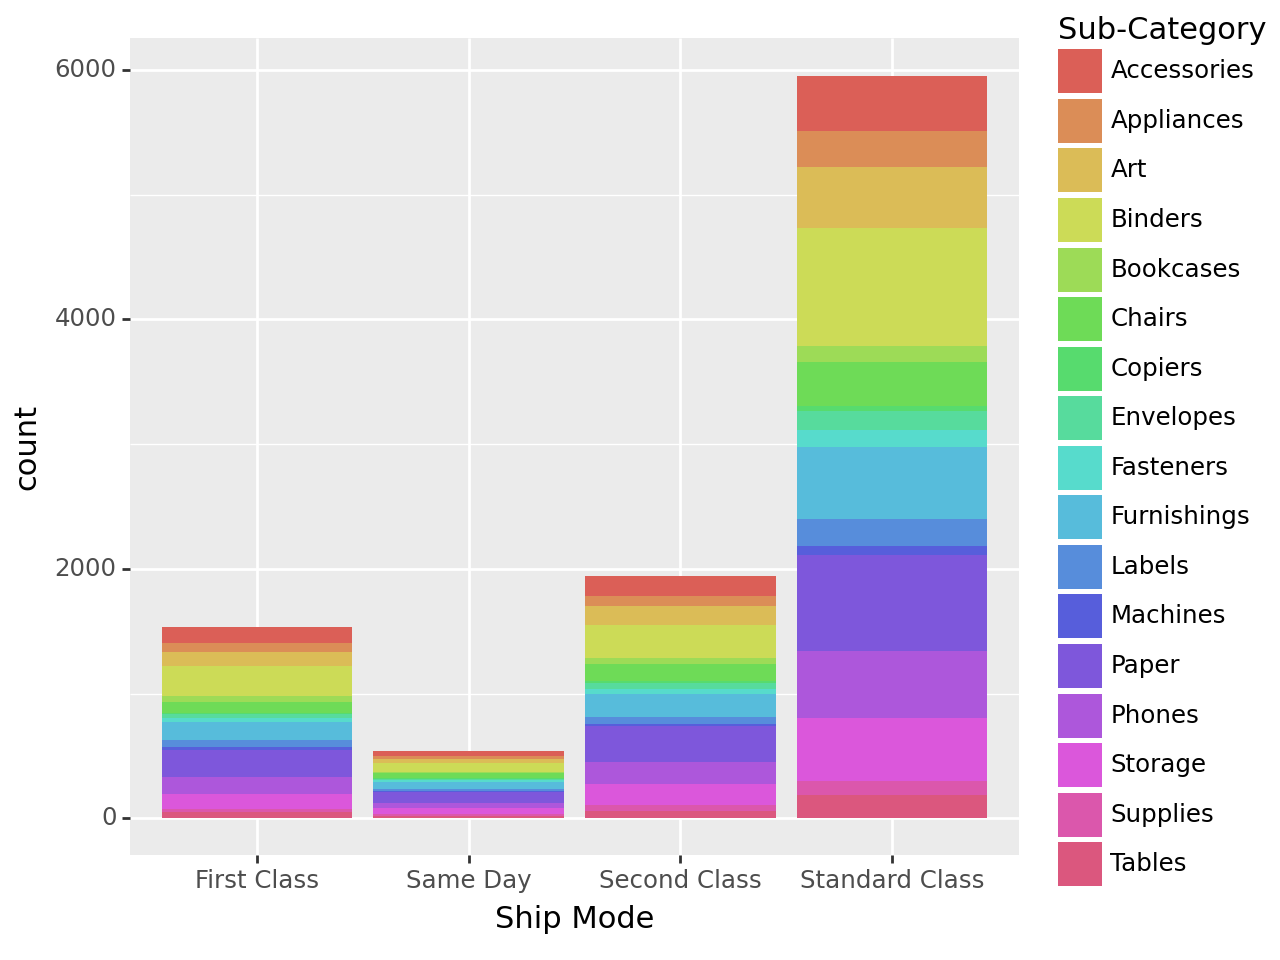

<Figure Size: (640 x 480)>

In [35]:
ggplot(data2, aes(x='Ship Mode',fill="Sub-Category")) +geom_bar(stat="count")

<Axes: xlabel='Ship Mode', ylabel='Profit'>

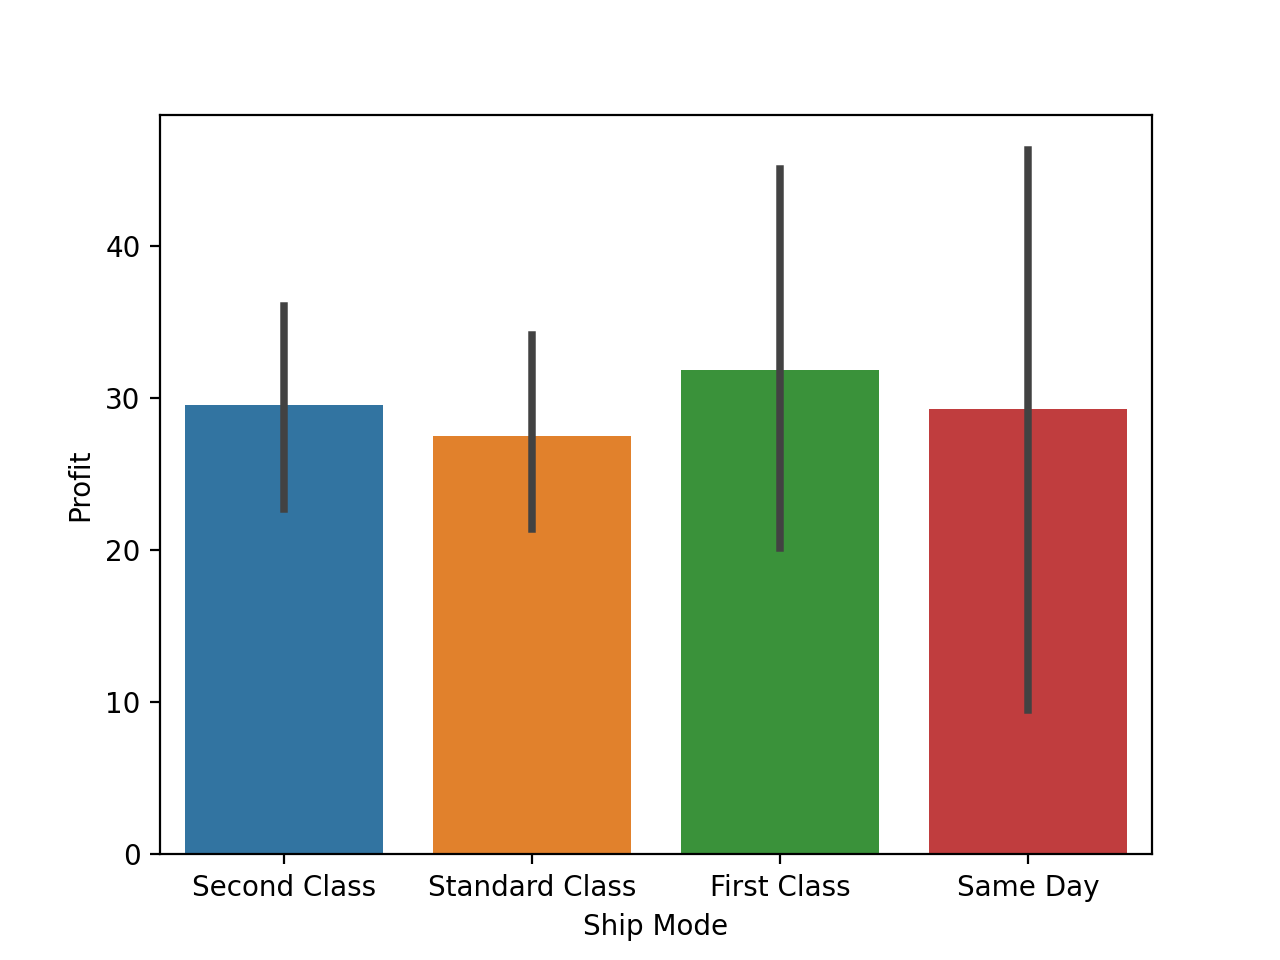

In [36]:
sns.barplot(data=data2,x="Ship Mode",y="Profit")

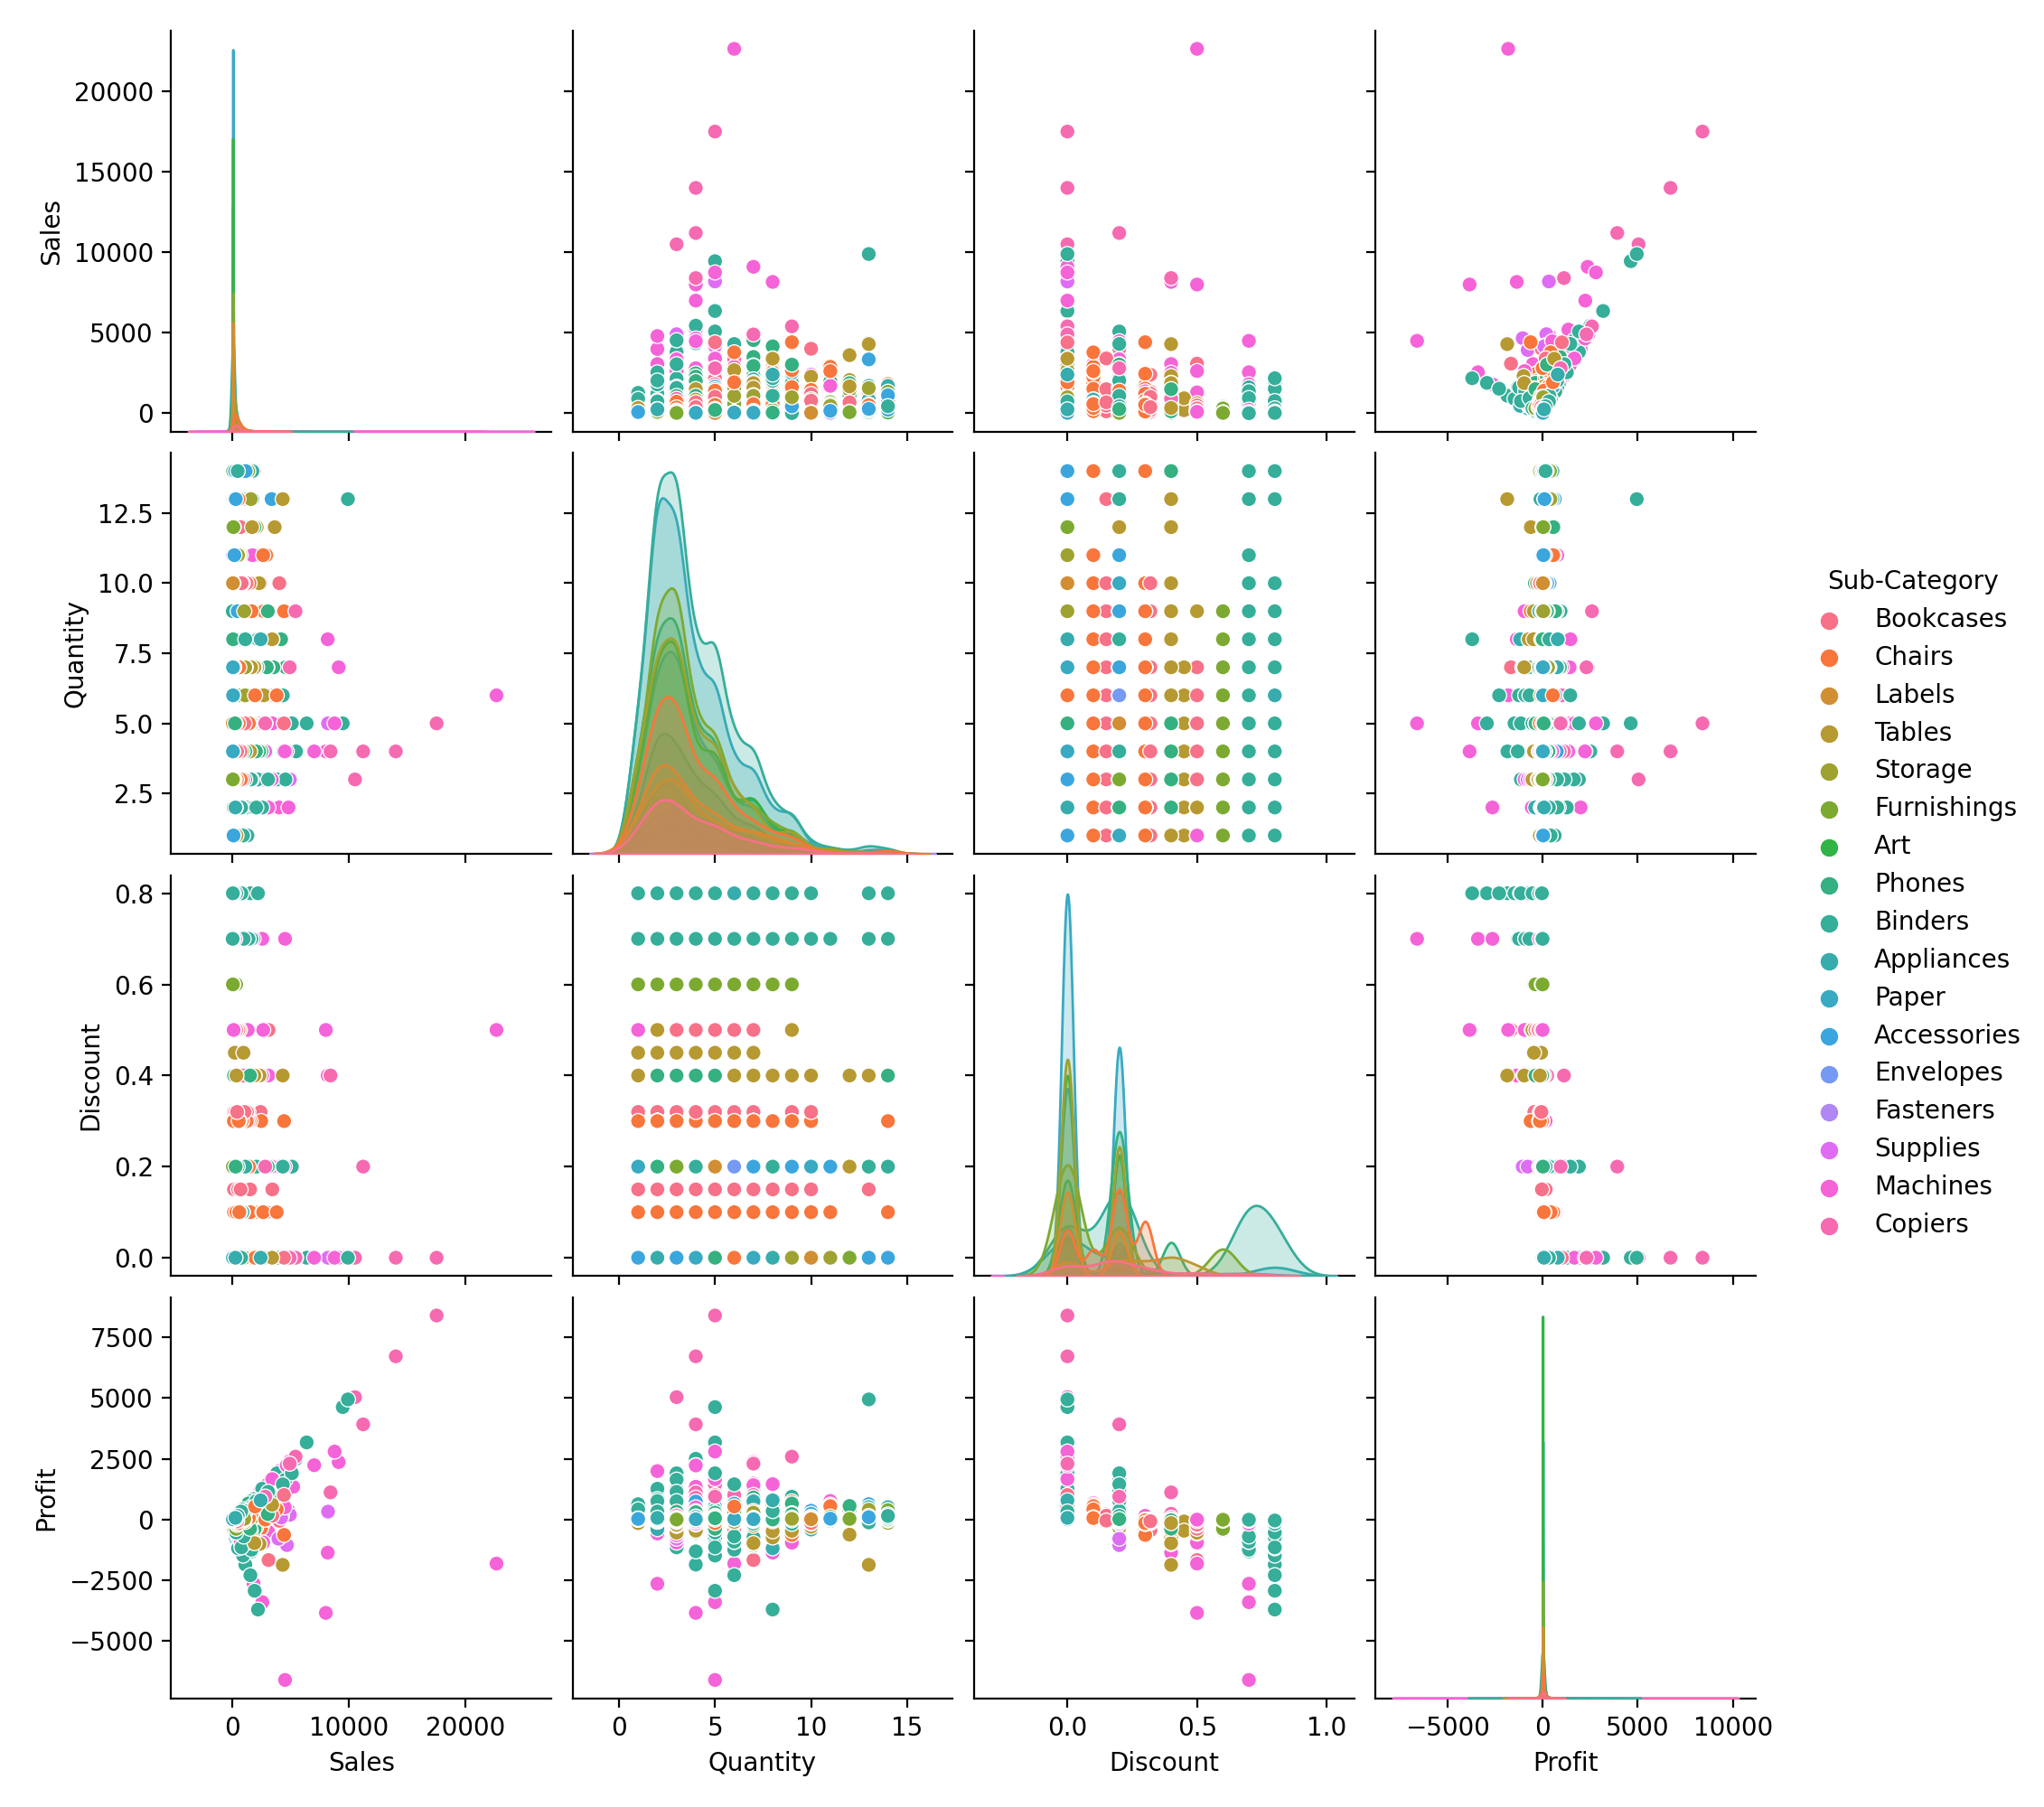

In [37]:
sns.pairplot(data2,hue="Sub-Category")

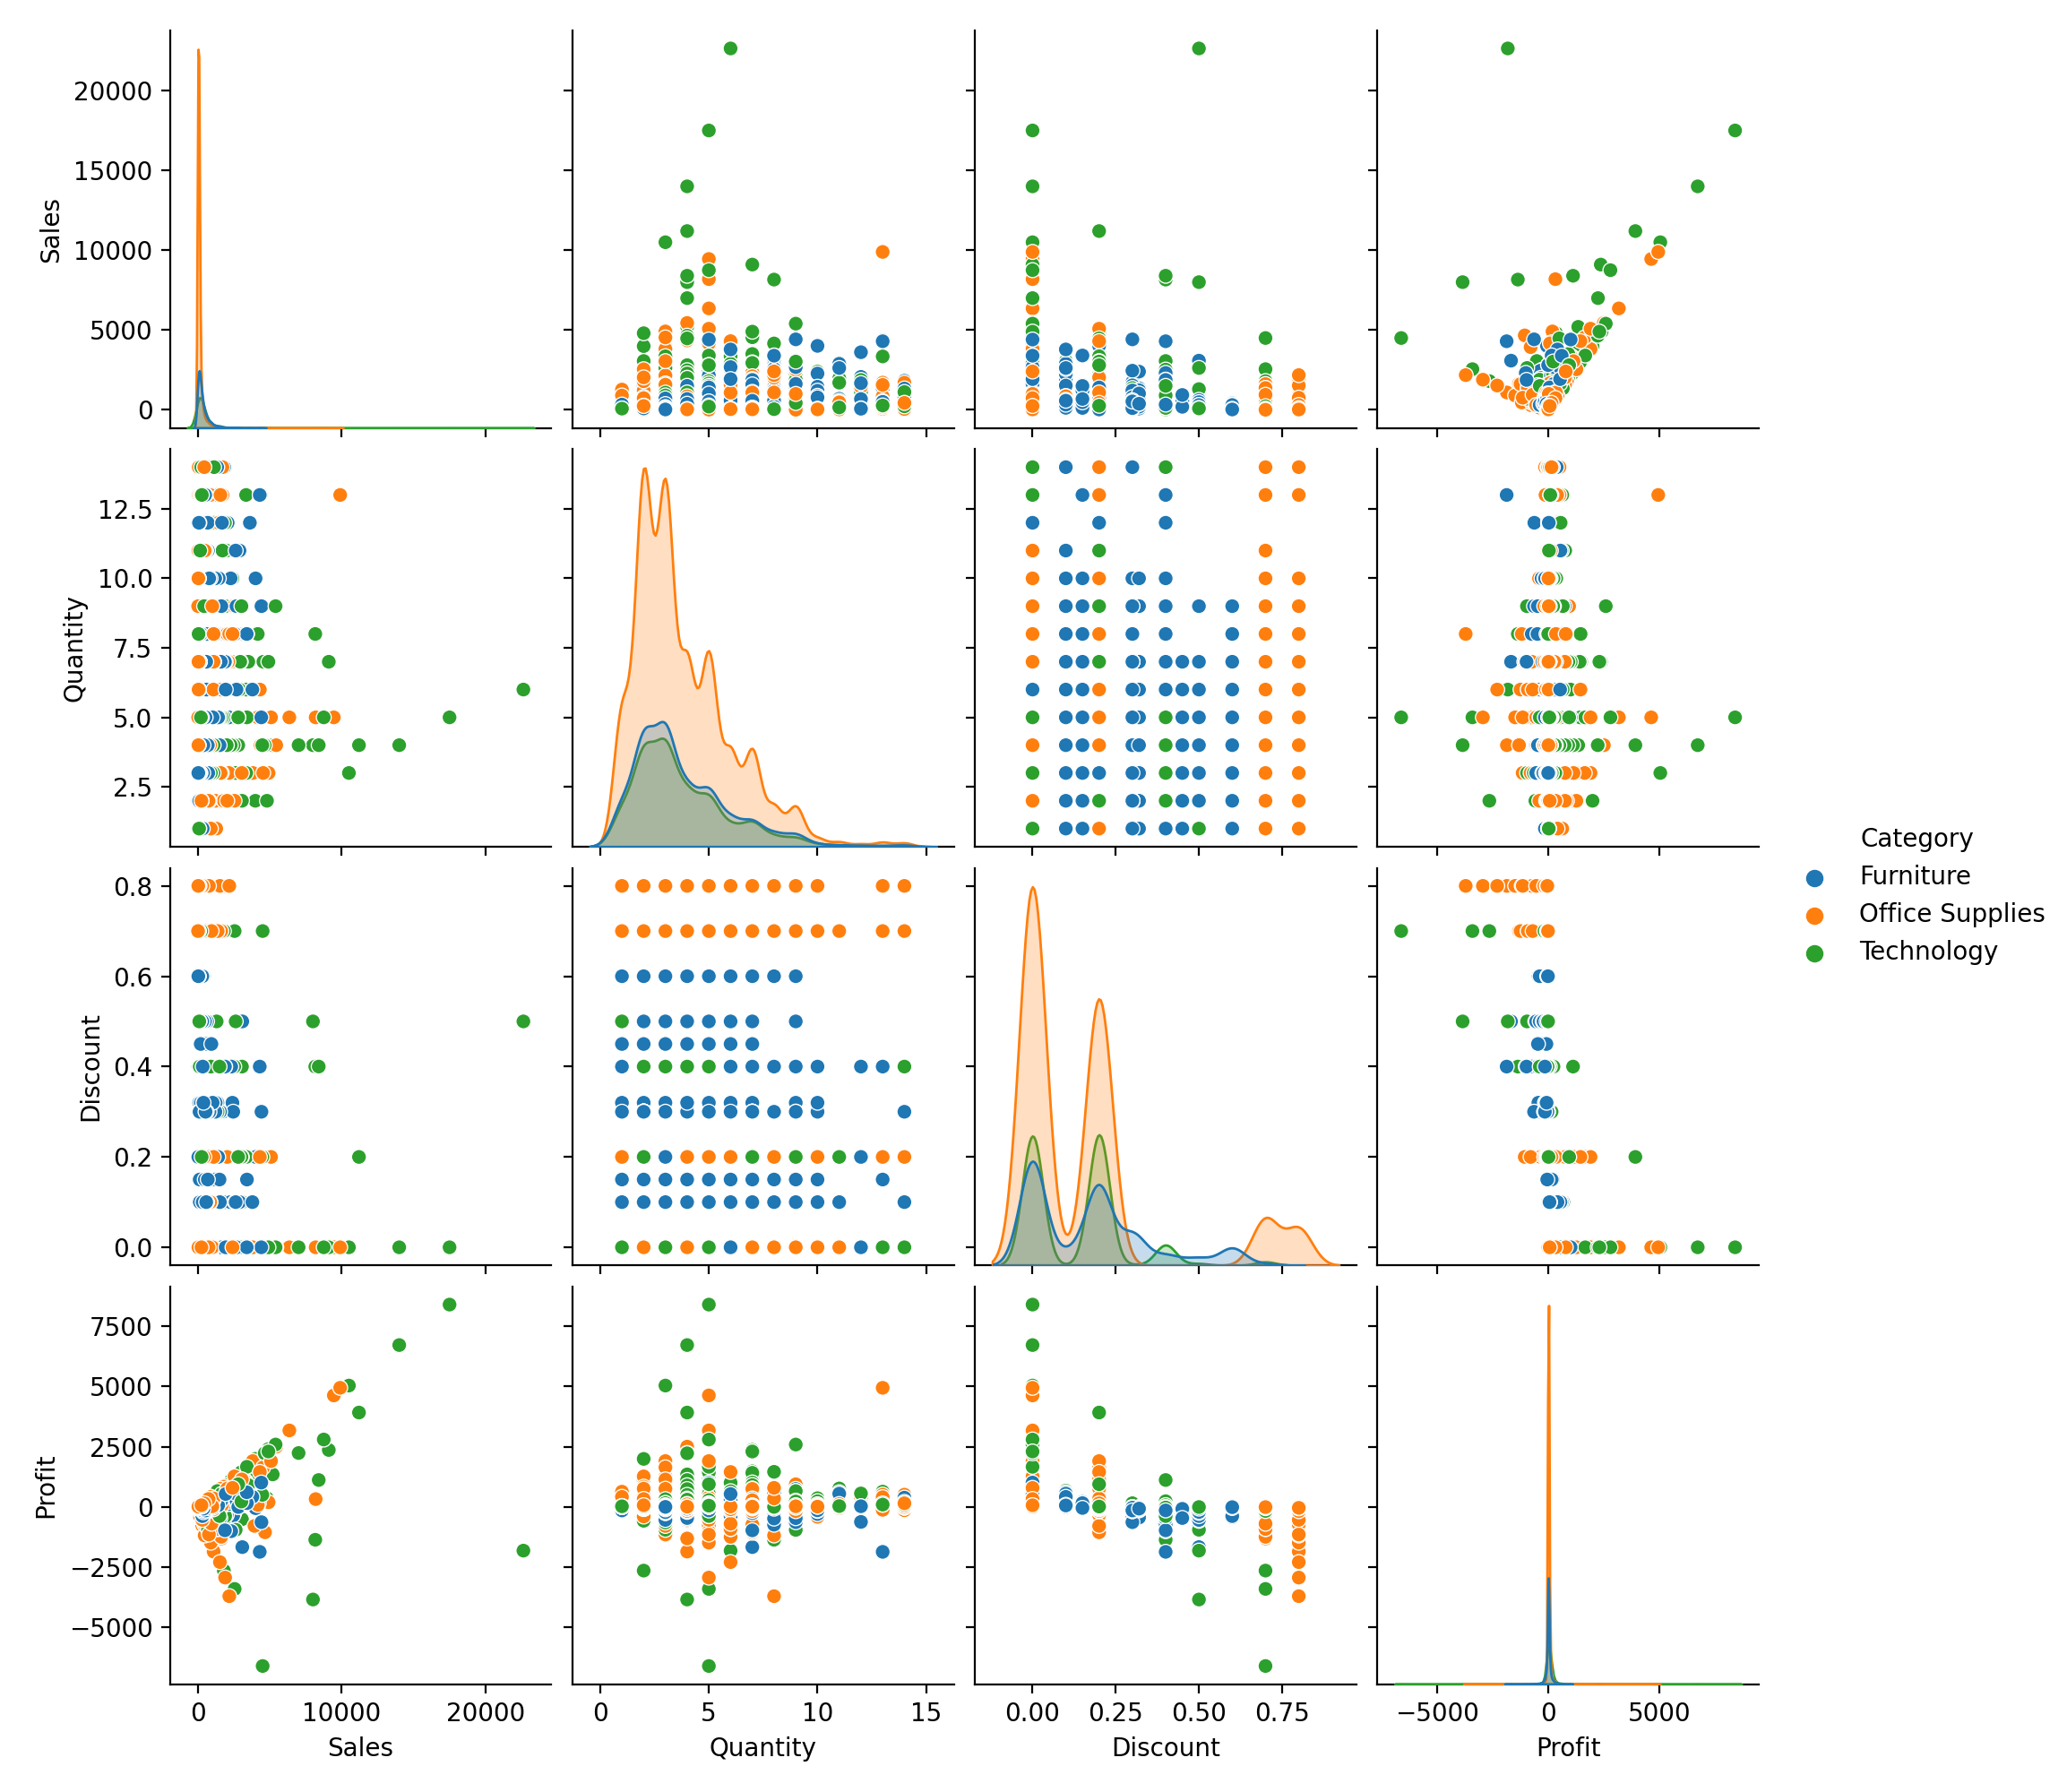

In [38]:
sns.pairplot(data2,hue="Category")

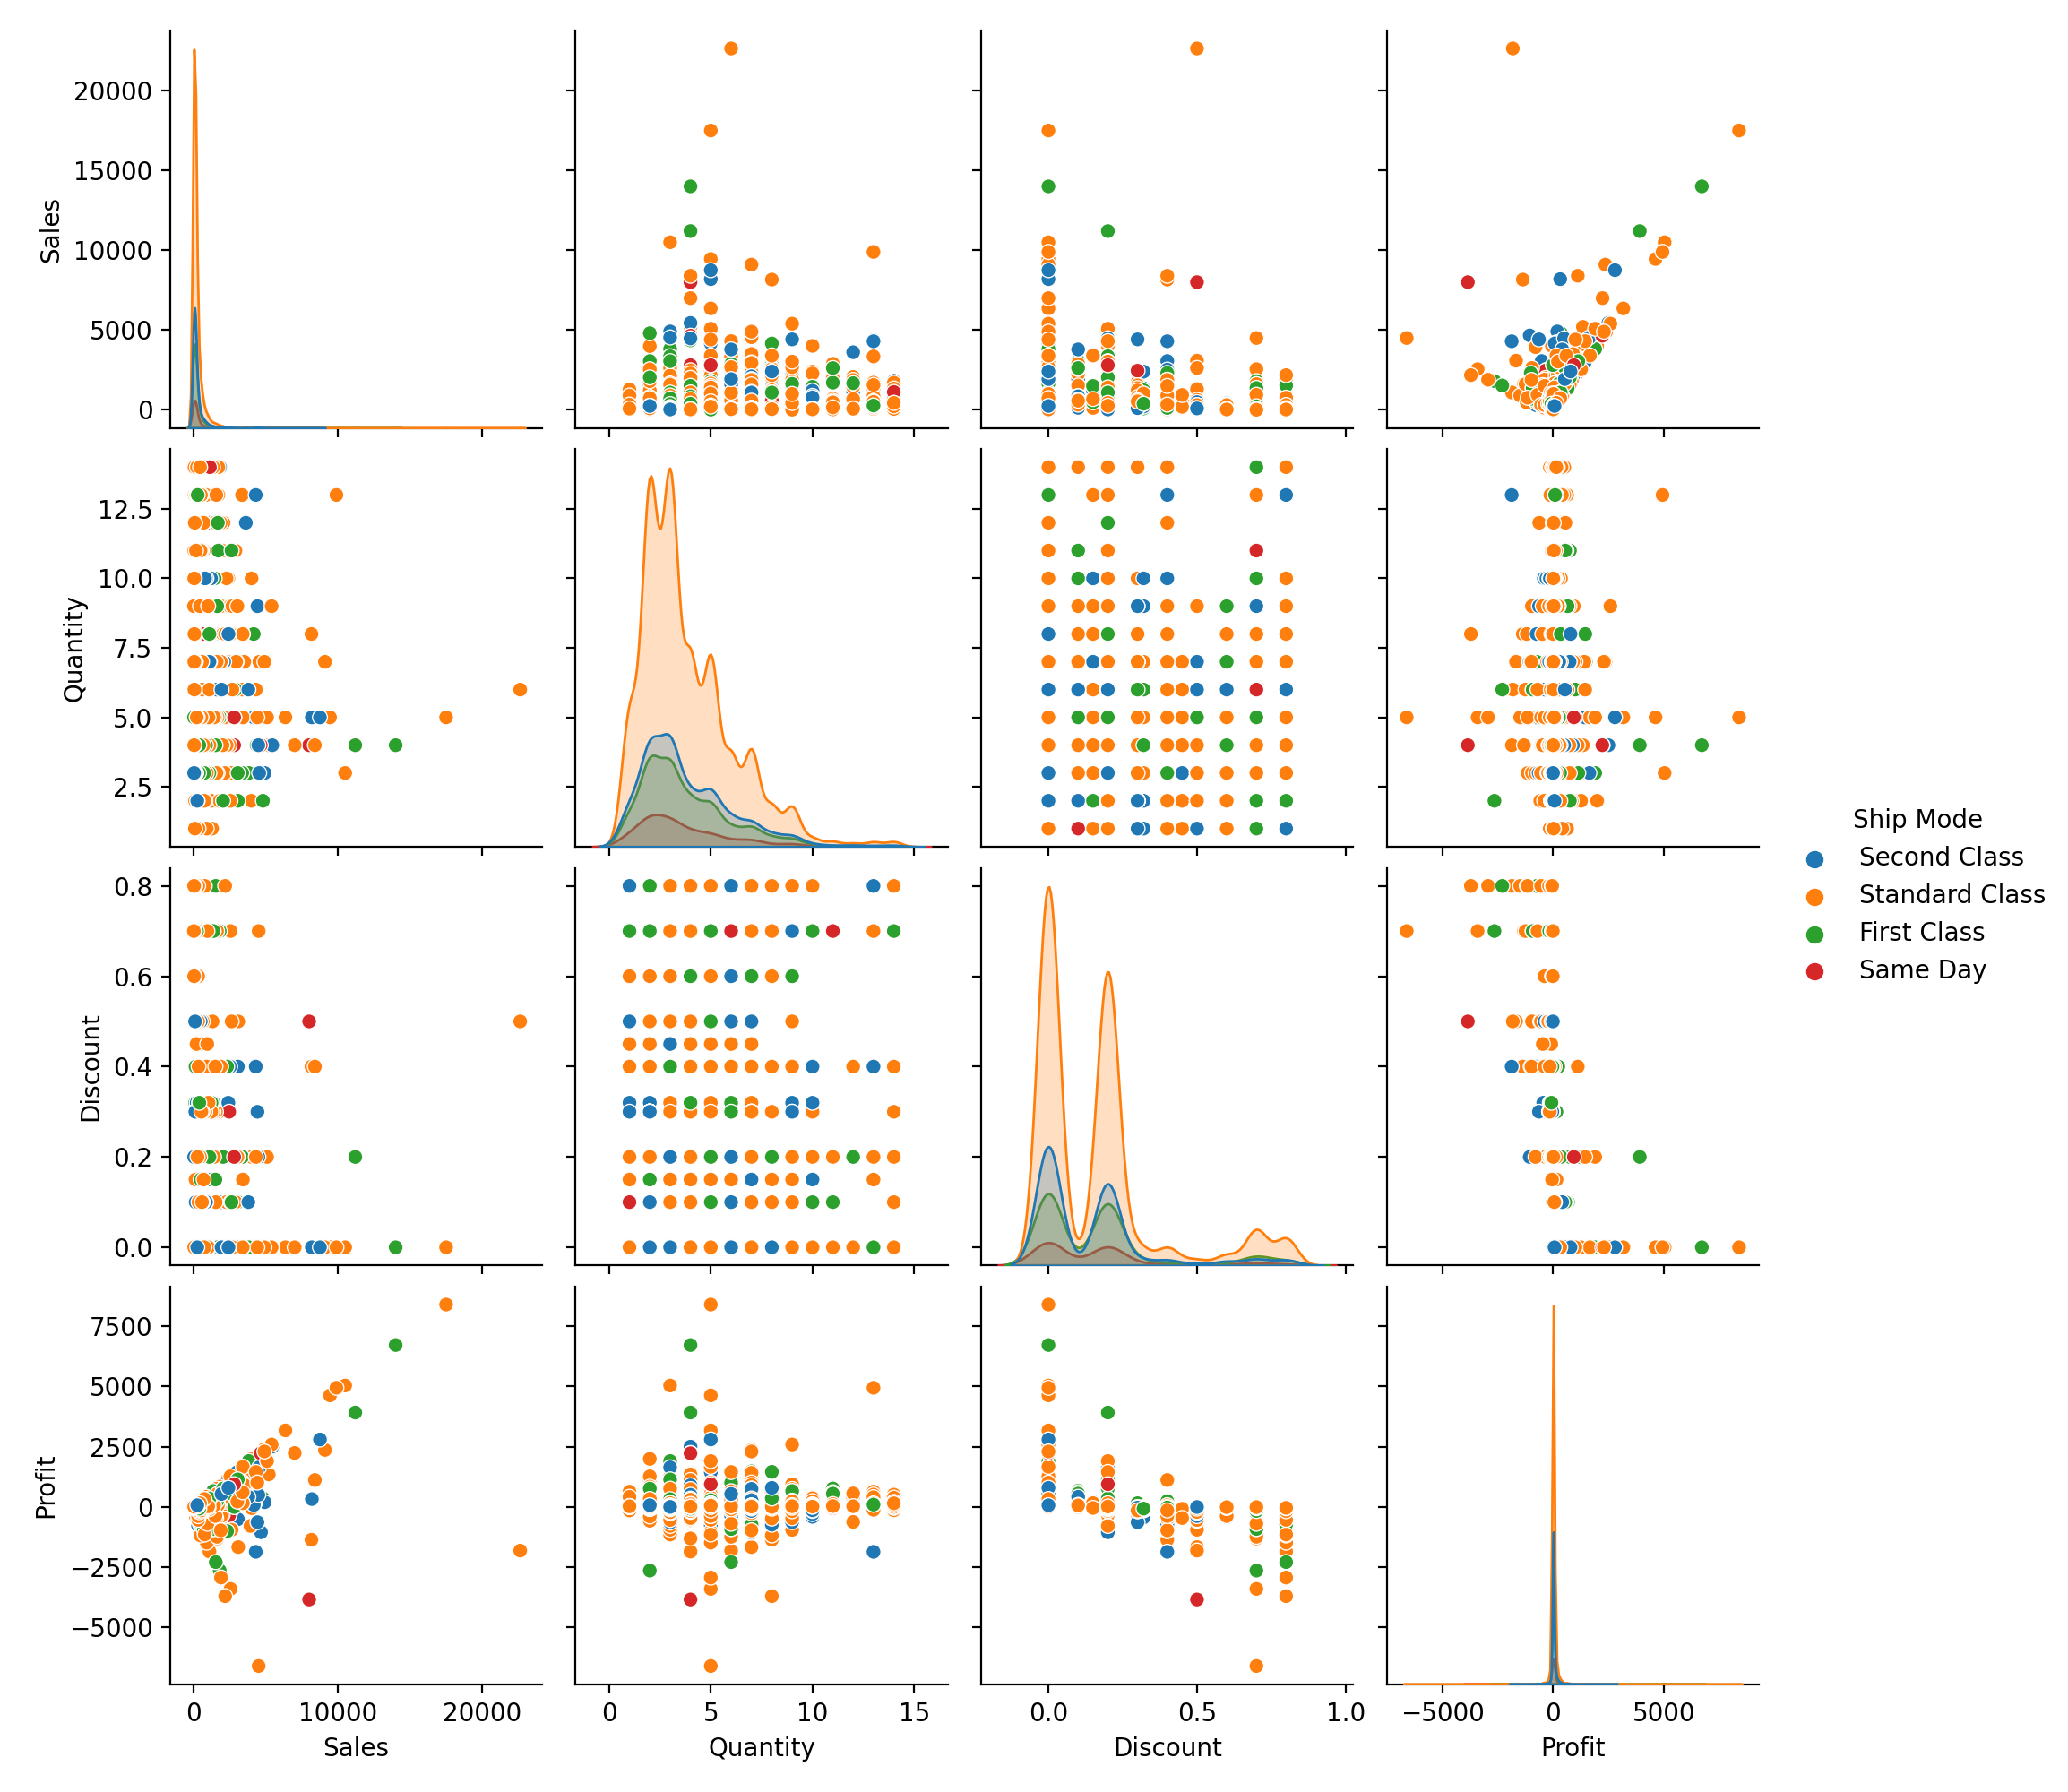

In [39]:
sns.pairplot(data2,hue="Ship Mode")

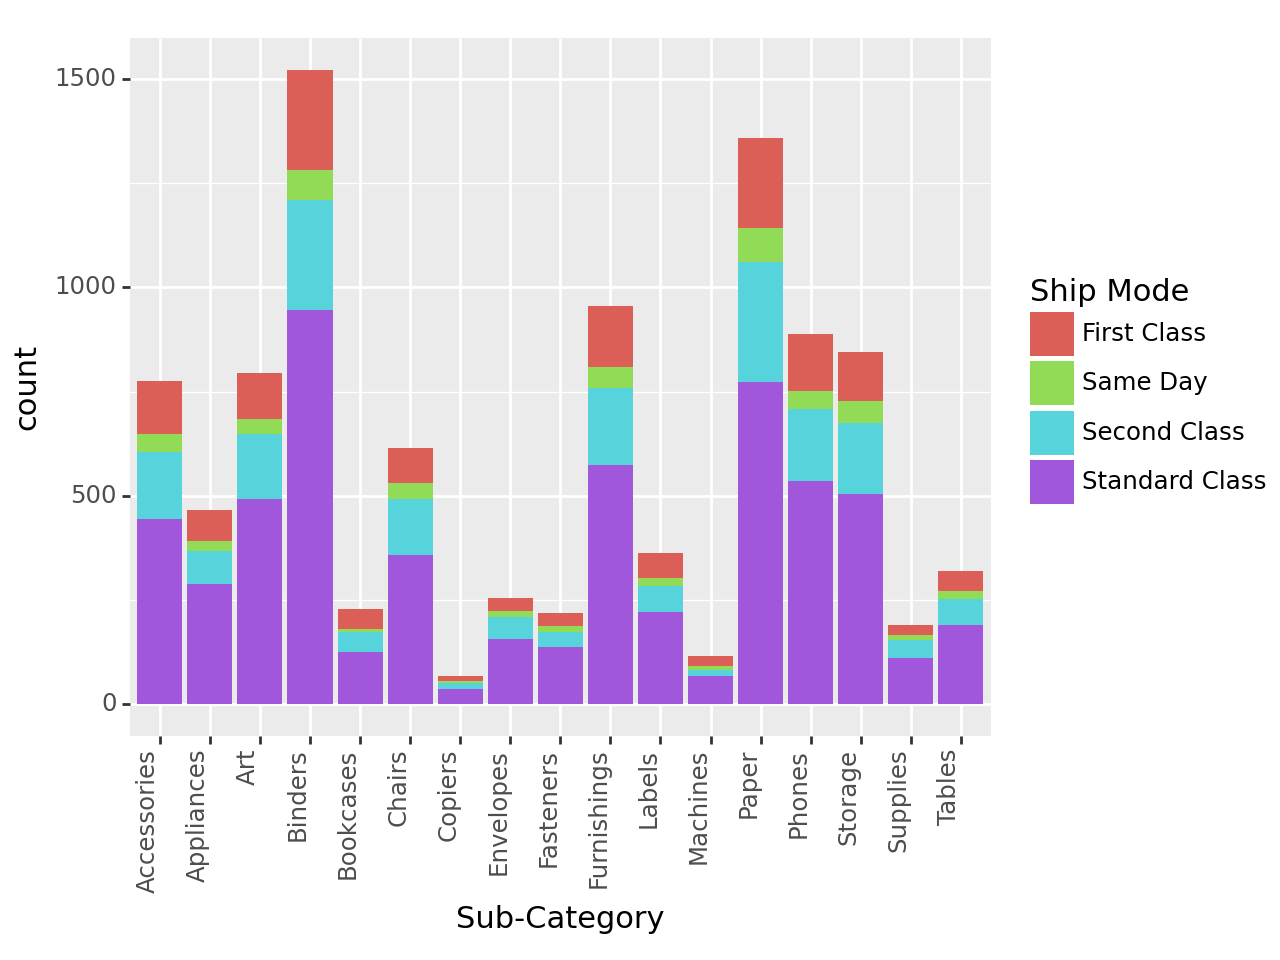

<Figure Size: (640 x 480)>

In [48]:
flip_xlabels=theme(axis_text_x = element_text(angle=90, hjust=1))
ggplot(data2, aes(x='Sub-Category', fill='Ship Mode')) + geom_bar() + flip_xlabels

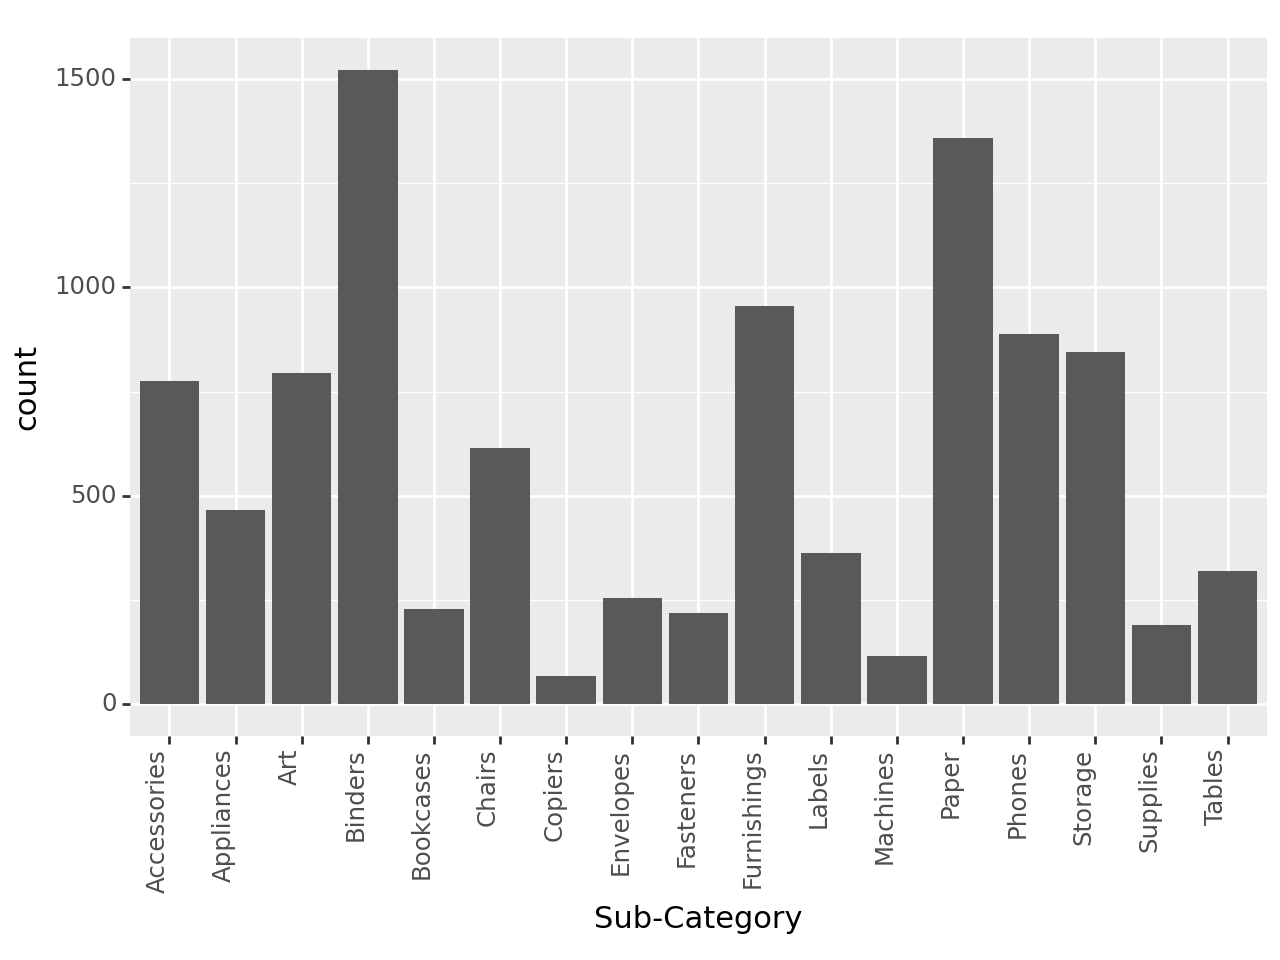

<Figure Size: (640 x 480)>

In [52]:
flip_xlabels=theme(axis_text_x = element_text(angle=90, hjust=1))
ggplot(data2, aes(x='Sub-Category', fill='Discount')) + geom_bar() + flip_xlabels


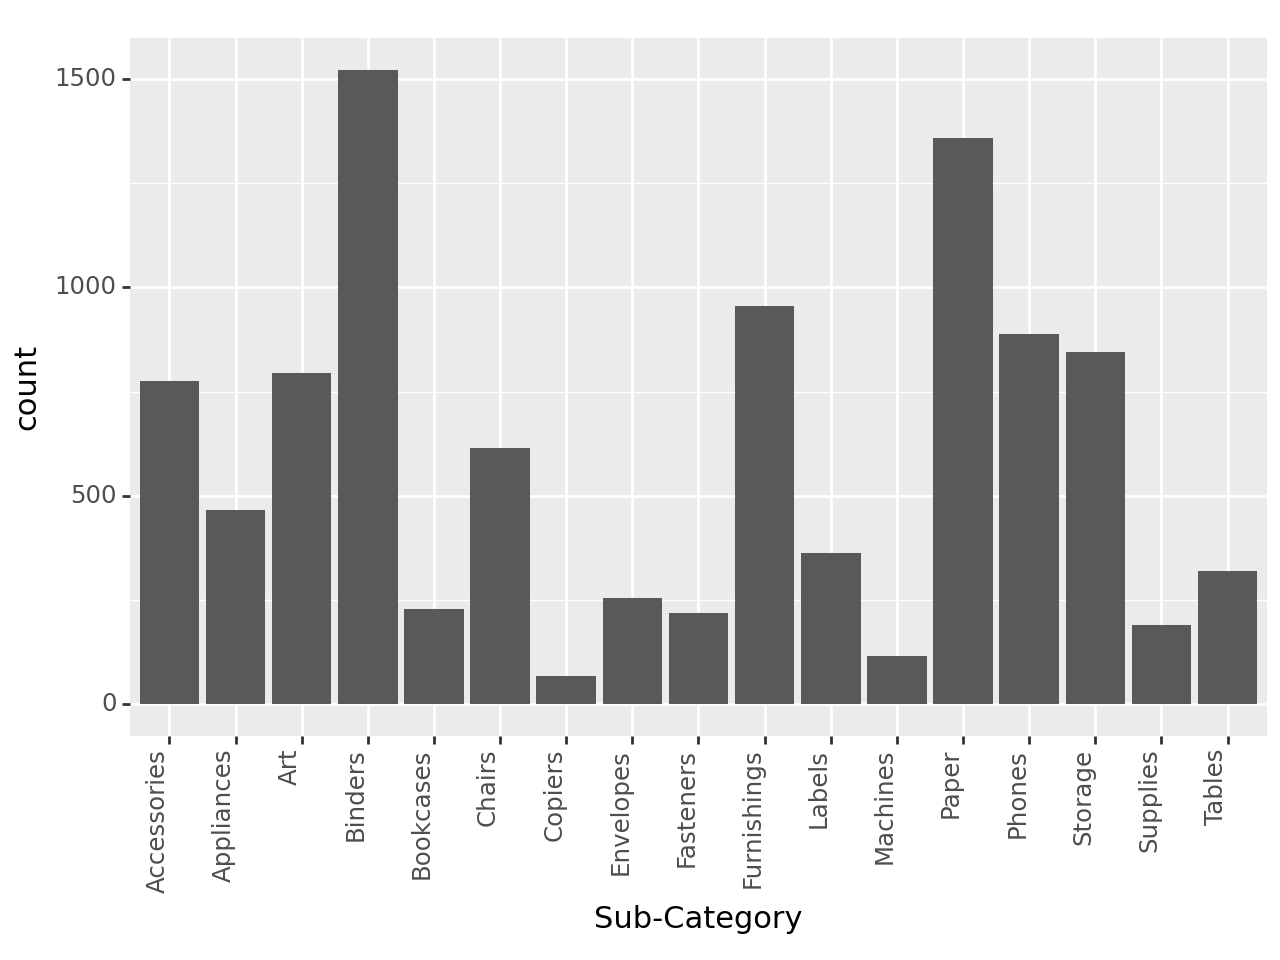

<Figure Size: (640 x 480)>

In [53]:
flip_xlabels=theme(axis_text_x = element_text(angle=90, hjust=1))
ggplot(data2, aes(x='Sub-Category', fill='Profit')) + geom_bar() + flip_xlabels

In [ ]:
# If we give discouts on other product then profit of that product increases like profits of Binders,Paprers,Furnishings then our P

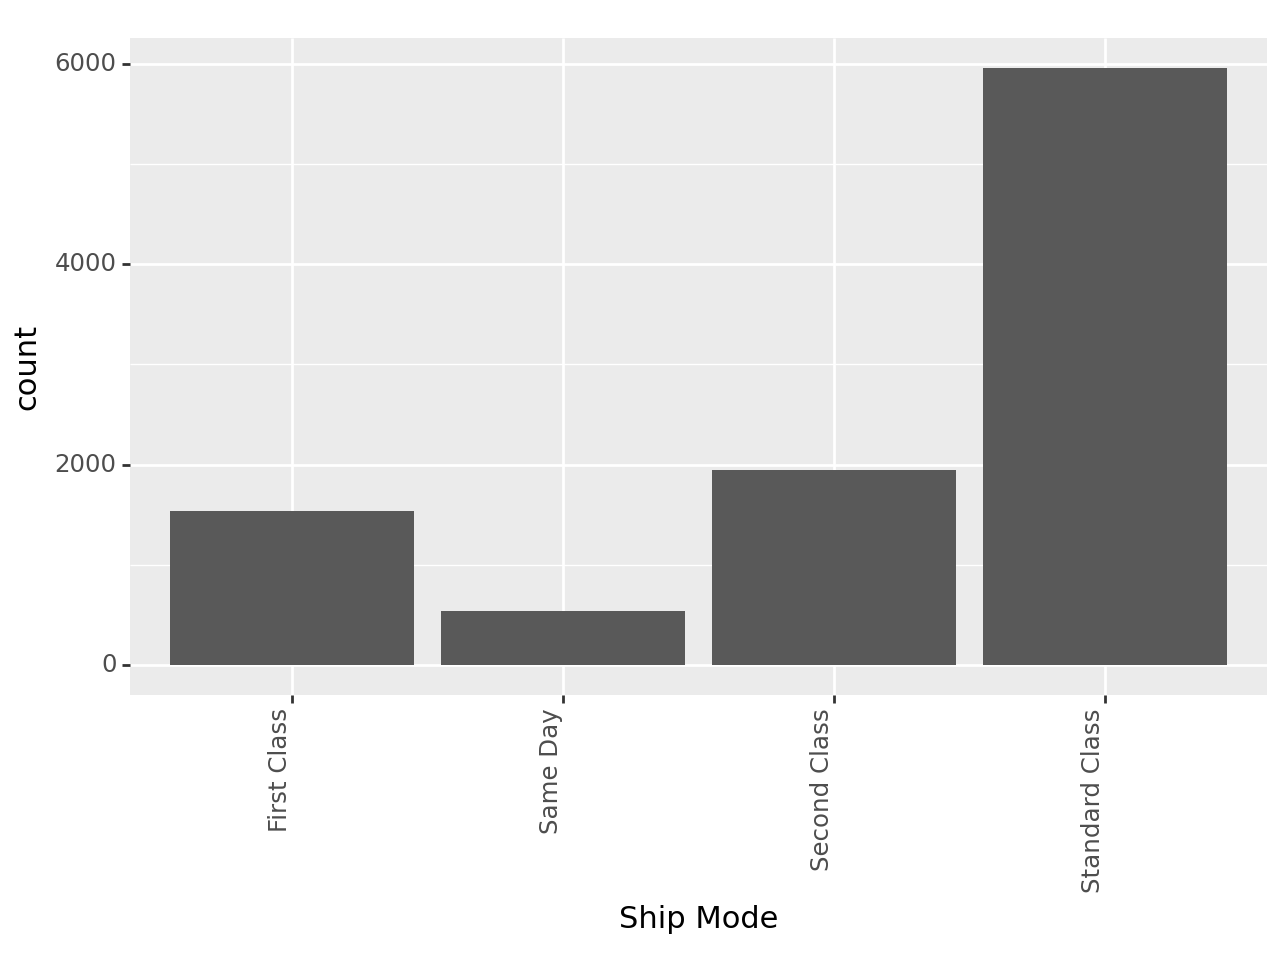

<Figure Size: (640 x 480)>

In [50]:
flip_xlabels=theme(axis_text_x = element_text(angle=90, hjust=1))
ggplot(data2, aes(x='Ship Mode', fill='Discount')) + geom_bar() + flip_xlabels

In [ ]:
# From the Above data we can see that if we give more discounts on the products then Standard Class People attracted Sales imporoves 

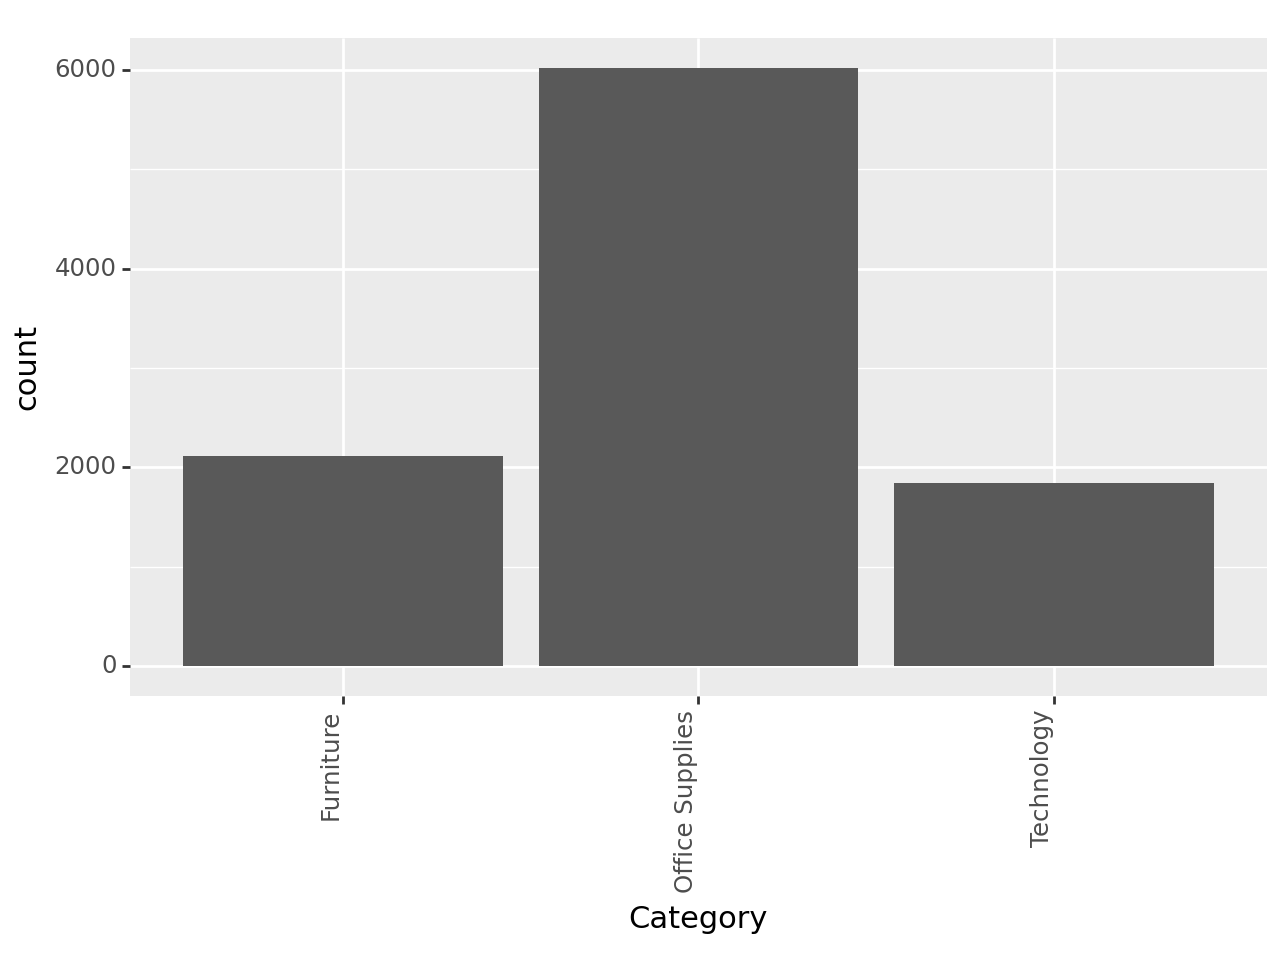

<Figure Size: (640 x 480)>

In [55]:
flip_xlabels=theme(axis_text_x = element_text(angle=90, hjust=1))
ggplot(data2, aes(x='Category', fill='Profit')) + geom_bar() + flip_xlabels

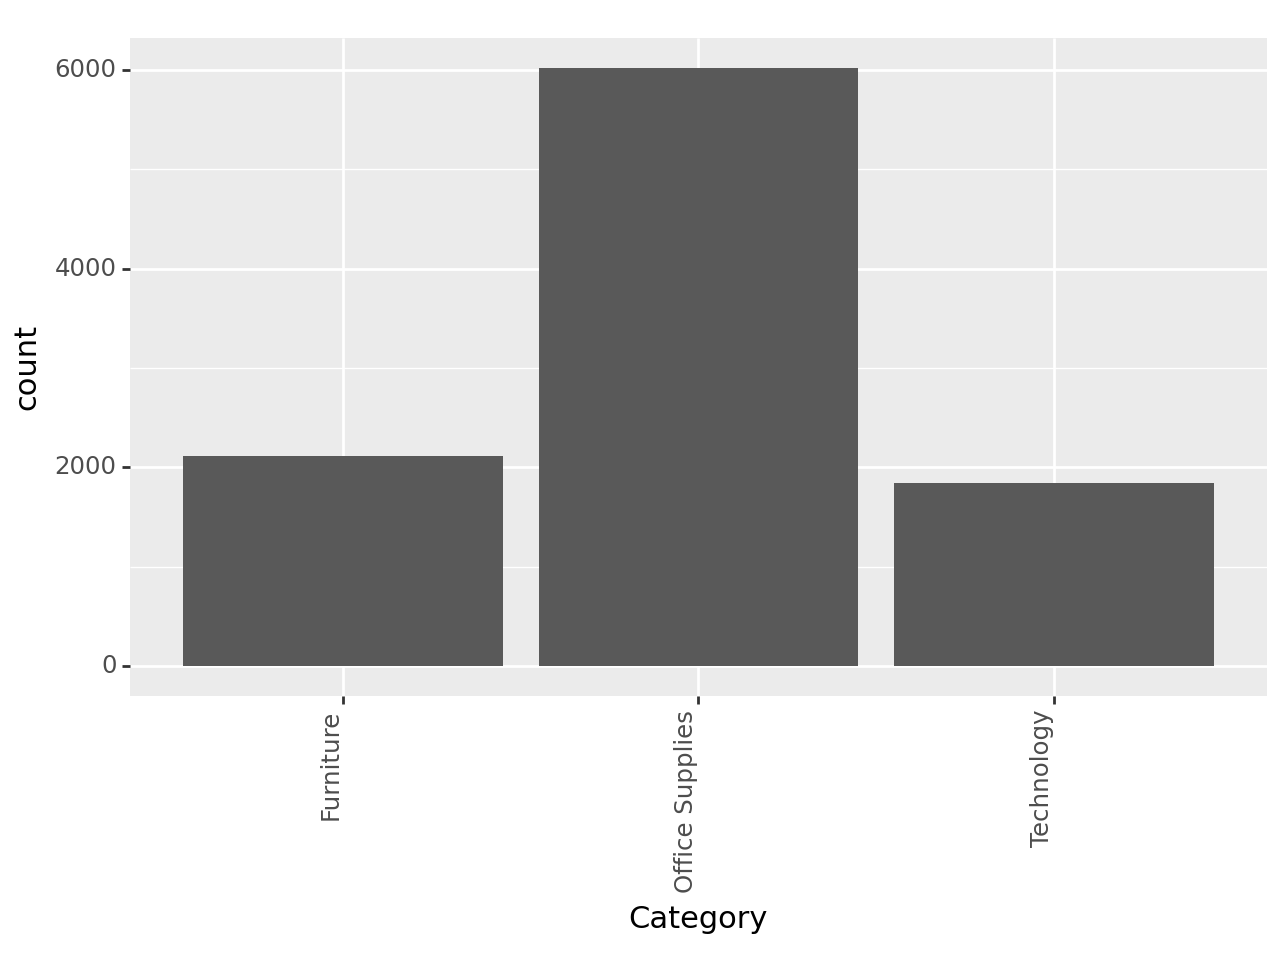

<Figure Size: (640 x 480)>

In [56]:
flip_xlabels=theme(axis_text_x = element_text(angle=90, hjust=1))
ggplot(data2, aes(x='Category', fill='Discount')) + geom_bar() + flip_xlabels

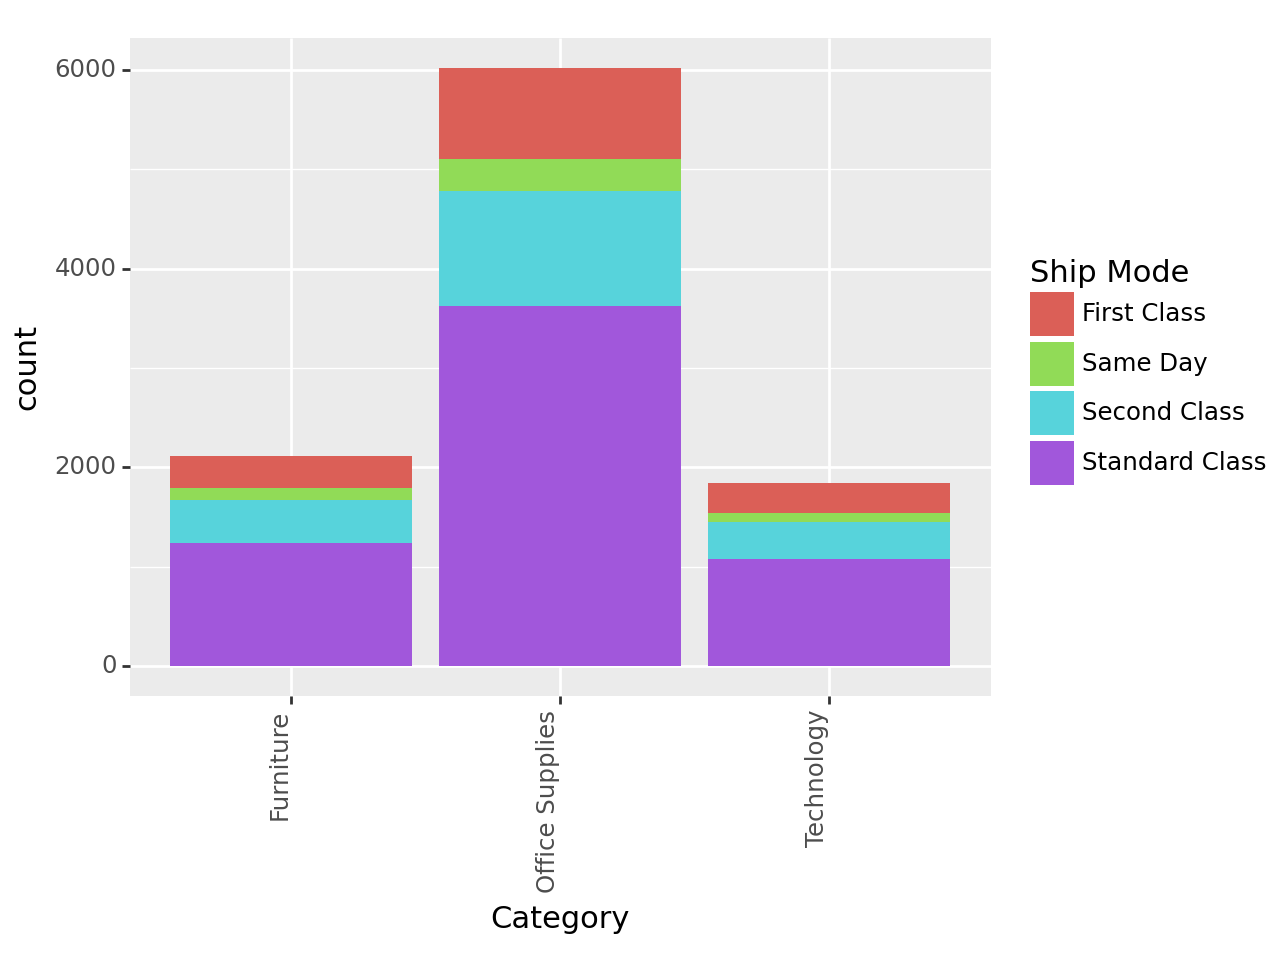

<Figure Size: (640 x 480)>

In [57]:
flip_xlabels=theme(axis_text_x = element_text(angle=90, hjust=1))
ggplot(data2, aes(x='Category', fill='Ship Mode')) + geom_bar() + flip_xlabels

In [58]:
# In Category of Office Supplies profits are incearsed due to More discount on it.
# Compared to Furnitures and Technology the Office Supplies 

In [ ]:
# From the above data we can say that people are buying more Binders,Paprers,Furnishings from Standard Class

In [59]:
data2.head(6)

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,West,Furniture,Furnishings,48.8600,7,0.00,14.1694


In [60]:
## We have a few questions to answer here.

# 1 What products do the most profit making states buy?
# 2 What products do the loss bearing states buy?
# 3 What product segment needs to be improved in order to drive the profits higher?

In [63]:
def state_data_viewer(states):
    """Plots the turnover generated by different product categories and sub-categories for the list of given states.
    Args:
        states- List of all the states you want the plots for
    Returns:
        None
    """
    product_data = data2.groupby(['State'])
    for state in states:
        data = product_data.get_group(state).groupby(['Category'])
        fig, ax = plt.subplots(1, 3, figsize = (28,5))
        fig.suptitle(state, fontsize=14)        
        ax_index = 0
        for cat in ['Furniture', 'Office Supplies', 'Technology']:
            cat_data = data.get_group(cat).groupby(['Sub-Category']).sum()
            sns.barplot(x = cat_data.Profit, y = cat_data.index, ax = ax[ax_index])
            ax[ax_index].set_ylabel(cat)
            ax_index +=1
        fig.show()

C:\Users\vishn\AppData\Local\Temp\ipykernel_12428\3826856385.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
C:\Users\vishn\AppData\Local\Temp\ipykernel_12428\3826856385.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
C:\Users\vishn\AppData\Local\Temp\ipykernel_12428\3826856385.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
C:\Users\vishn\AppData\Local\Temp\ipykernel_12428\3826856385.py:19: UserWarning: Matplot

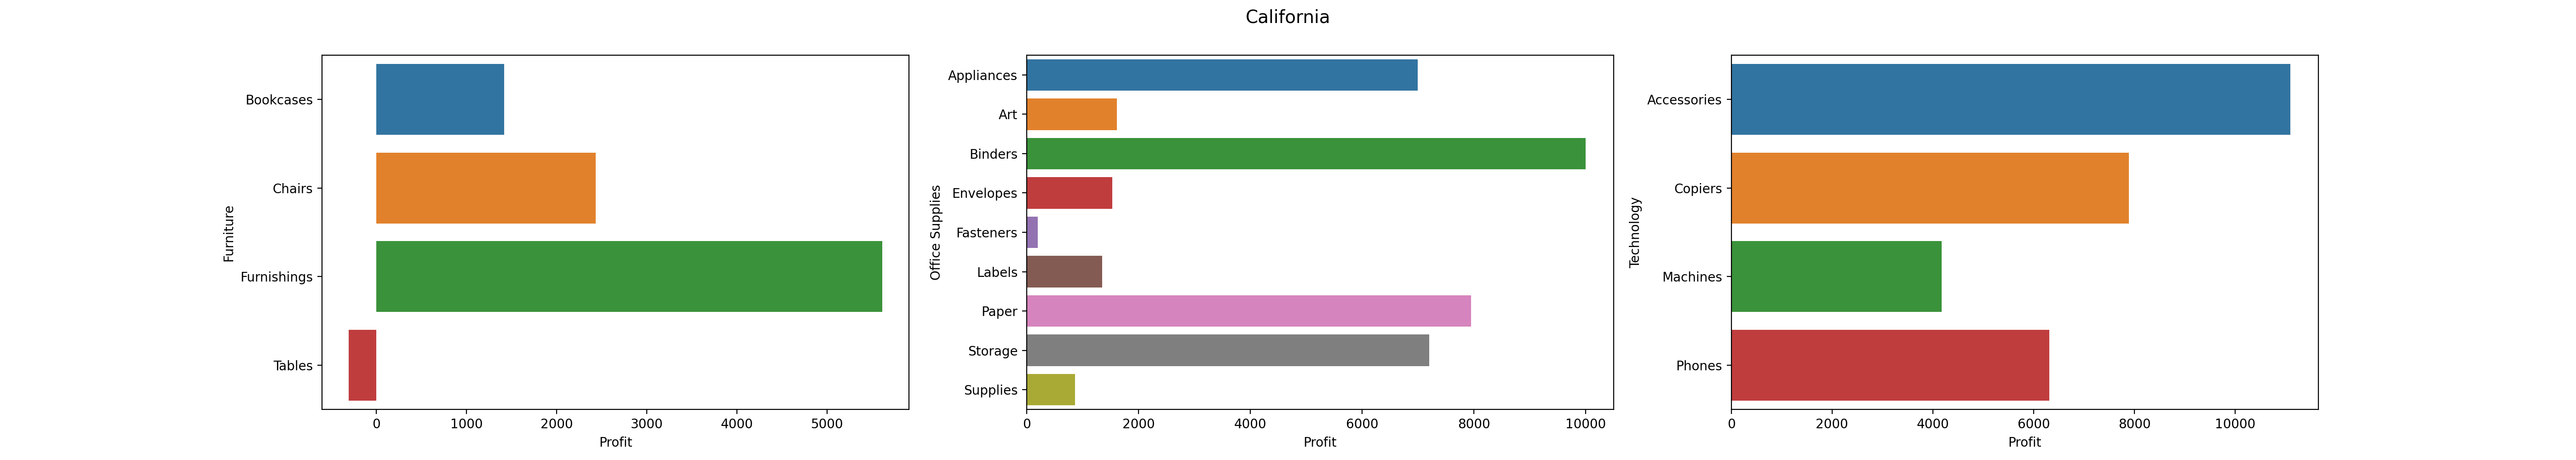

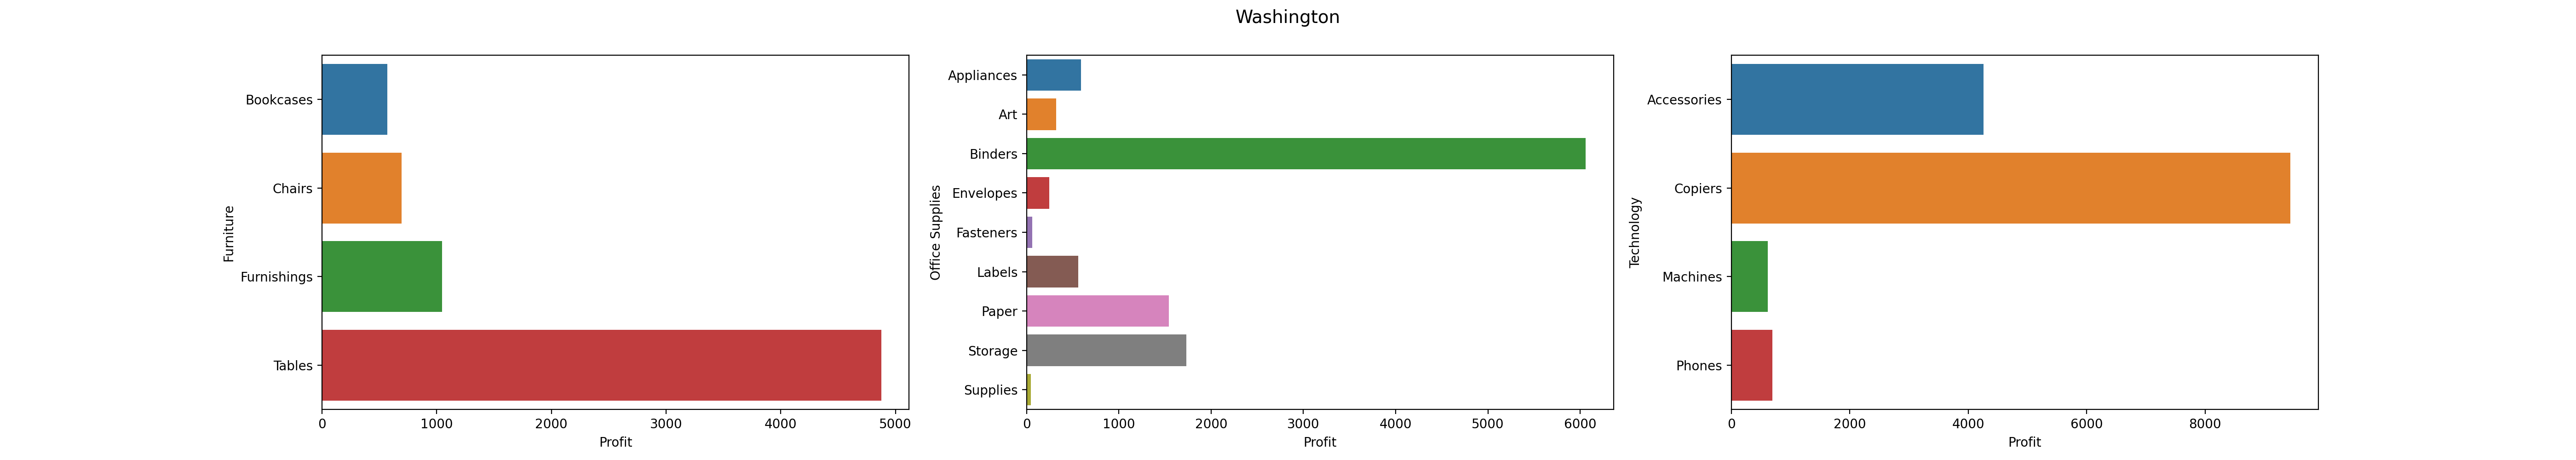

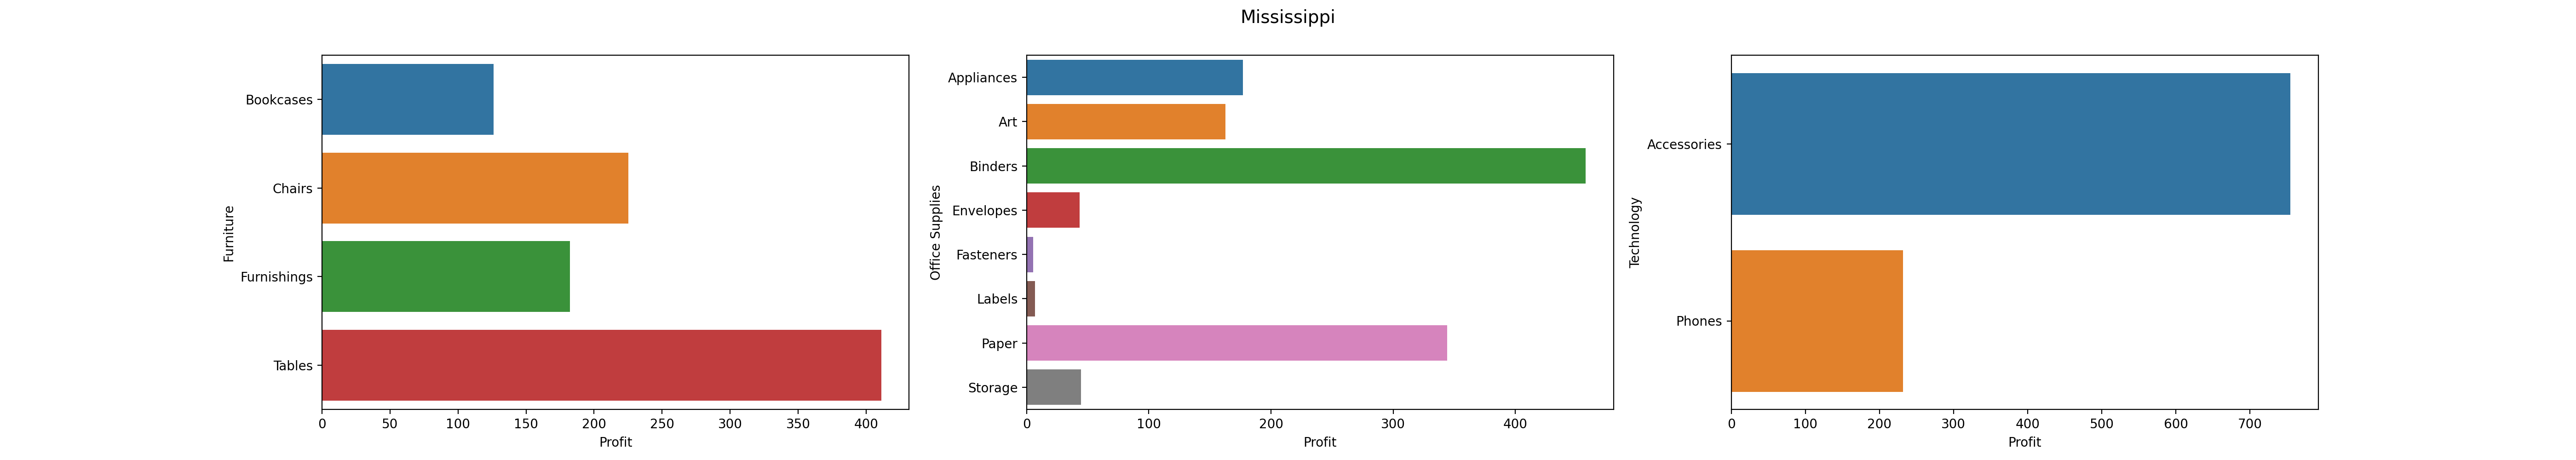

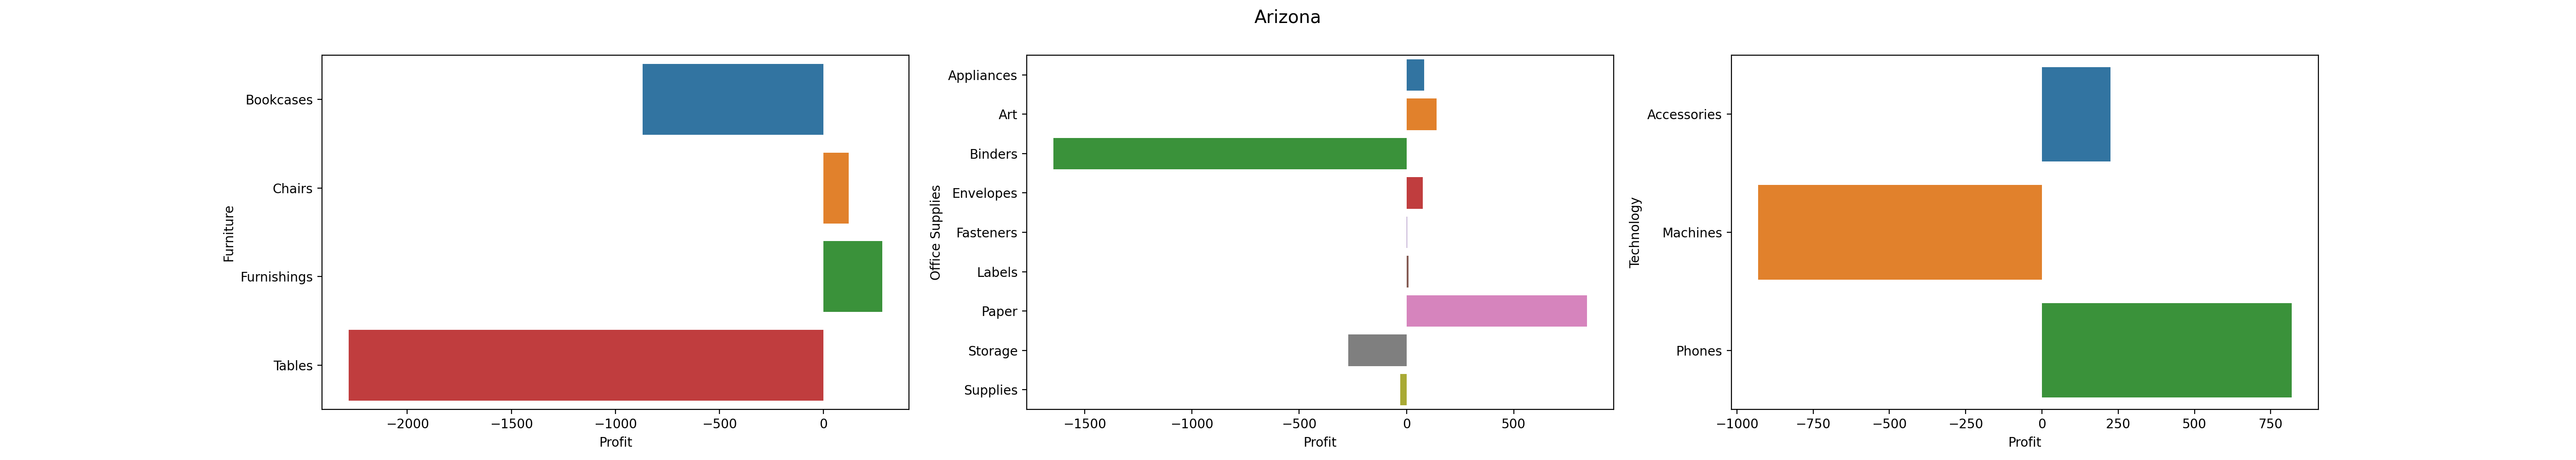

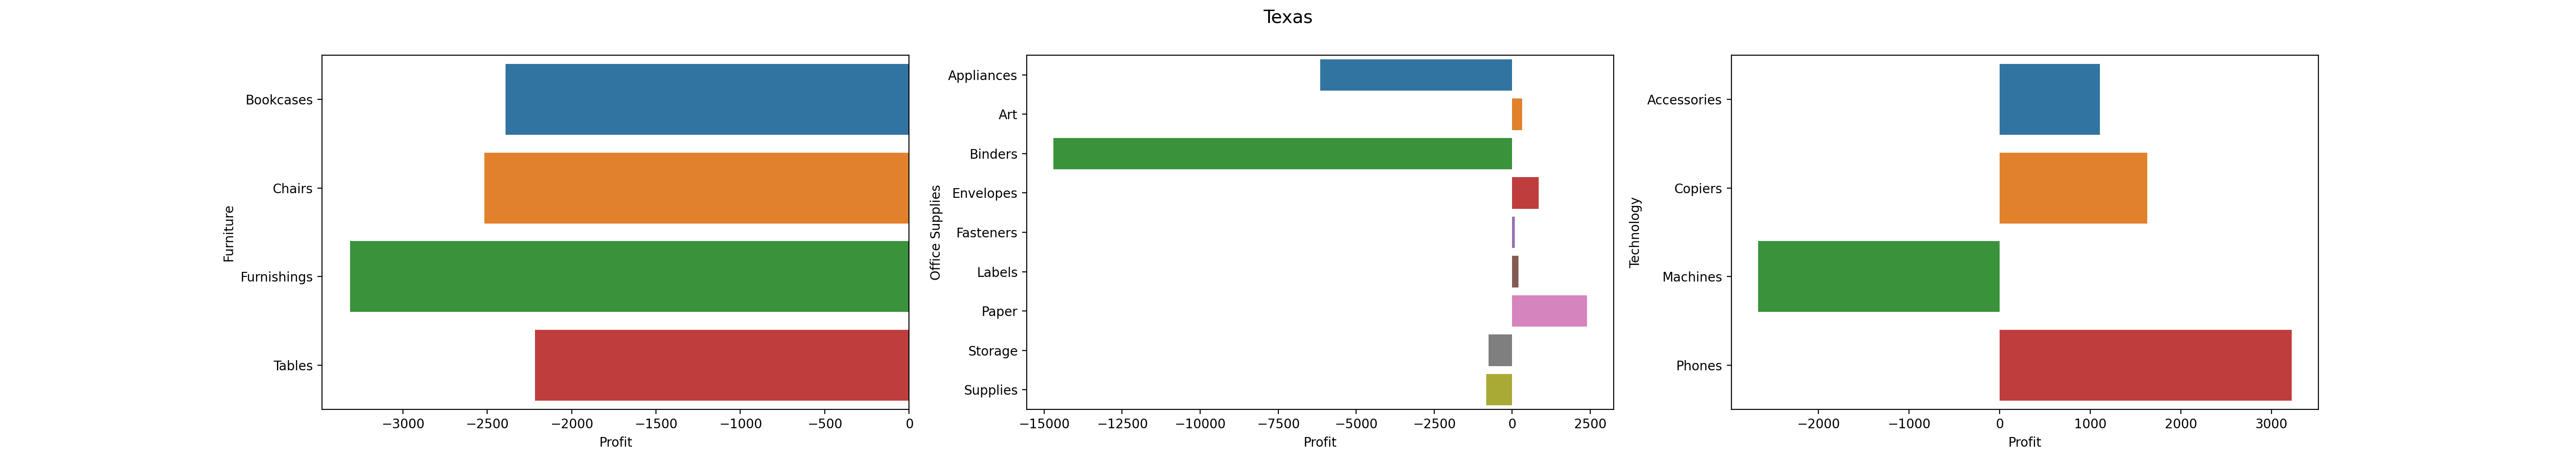

In [64]:
states = ['California', 'Washington', 'Mississippi', 'Arizona', 'Texas']
state_data_viewer(states)

# Conclusion

In [ ]:
# More Profitting Areas such as 'California', 'Washington', 'Mississippi', 'Arizona', 'Texas' and more
# We most also focus on loss to Overcome not only on Profit 
# We must stable maintain discount and overcome the loss buy targeting area such as 'California', 'Washington', 'Mississippi', 'Arizona', 'Texas'
# These States has more Profit.